# **Database**: General Overview

*   This notebook features the code and figures from the paper:

**"The Grammar of Transformers: A Systematic Review of Interpretability Research on Syntactic Knowledge in Language Models"**  
*Authors: Nora Graichen and Iria de-Dios-Flores and Gemma Boleda*  
Accepted at EMNLP 2026
[https://arxiv.org/abs/2601.19926]

*   If you use our database, please cite our paper:)
*   Run the whole notebook (section) in one go, after having uploaded the needed files (database_final.csv) and running the subsequent module import/aux. functions


This notebook provides a structured analysis of our database focusing on three dimensions:

---

## 1️⃣ **Chronological Overview & Model-Type Influence**

- Plot publication trends over time (include model milestones such as BERT and ChatGPT releases)
- Identify shifts in research focus across model families

---

## 2️⃣ **Linguistic Phenomena & Language Coverage**

- Categorize papers by linguistic phenomenon
- Analyze language distribution across studies
- Evaluate benchmark usage

---

## 3️⃣ **Methods & Mechanistic Interpretability Approaches**

- Categorize studies by methodological approach
- Compare probing vs mechanistic interpretability methods
- Identify trends and compare language/linguistic phenomena distribution



# 0. Module imports, auxiliary functions, data loading



In [1]:
import pandas as pd
import plotly.express as px
import ast
import json
import re
import os
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import numpy as np
import pandas as pd
import seaborn as sns
from itertools import combinations
from plotly.colors import qualitative
from textwrap import fill
from scipy.stats import chi2_contingency
from scipy.stats import chisquare
import random
from matplotlib.patches import Patch

df = pd.read_csv("database_final.csv", sep=";")
df.head()

,id,review,short_ref_and_url,url,year,exclusion_grounds,title,abstract,model_type,model_name,...,interp_category,probing,probing_location,Mechanistic_method,Mechanistic_Causal Nature,Mechanistic_Phase,Mechanistic_Locality,Mechanistic_Syntactic evidence/ awareness,interp_method,main_findings
0,1,{'X'},Tjuatja et al(2023),https://aclanthology.org/2023.starsem-1.14/,2023,NaN,Syntax and Semantics Meet in the “Middle”: Pro...,Recent advances in large language models have ...,causal,"[{'string': 'bloom 560m', 'family': 'BLOOM', '...",...,behavioral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,suite of prompting experiments,examined how Large LMs handle the intersection...
1,2,{'A'},Abdou etal(2019),https://aclanthology.org/D19-1593/,2019,NaN,Higher-order Comparisons of Sentence Encoder R...,Representational Similarity Analysis (RSA) is ...,bidir,"[{'string': 'bert-large', 'family': 'BERT', 'c...",...,mechanistic,NaN,NaN,Representational Similarity Analysis (RSA),Observation,Post-hoc,global,Solid yes,Representational Similarity Analysis (RSA),The study using Representational Similarity An...
2,3,{'A'},Acs etal (2023),https://www.cambridge.org/core/journals/natura...,2023,NaN,Morphosyntactic probing of multilingual BERT m...,We introduce an extensive dataset for multilin...,bidir,"[{'string': 'mbert', 'family': 'BERT', 'catego...",...,probing,1,NaN,NaN,NaN,NaN,NaN,NaN,"probing task as a triple of (language, POS, mo...",research on multilingual language models (mBER...
3,4,"{'X', 'A'}",Alajirami etal(2022),https://aclanthology.org/2022.acl-short.16/,2022,NaN,How does the pre-training objective affect wha...,"Several pre-training objectives, such as maske...",bidir,"[{'string': 'bert', 'family': 'BERT', 'categor...",...,probing,1,NaN,NaN,NaN,NaN,NaN,NaN,experiment with five different pre-training ob...,The study found that the type of pre-training ...
4,5,{'A'},Alleman etal(2021),https://aclanthology.org/2021.repl4nlp-1.27/,2021,NaN,Syntactic Perturbations Reveal Representationa...,While vector-based language representations fr...,bidir,"[{'string': 'bert-base-cased', 'case': 'cased'...",...,probing,1,NaN,NaN,NaN,NaN,NaN,NaN,swapping words in a sentence and comparing the...,Studies of BERT and its variants reveal that t...


In [2]:
# number of included studies:
len(df)

337

In [3]:
# Helper functions
def plot_counts(df: pd.DataFrame, col: str, title: str, n: int = 20, is_exploded: bool = False):
    """
    Generate and display a bar chart for value counts. Handles list-type columns by exploding them first.
    """
    # Explode if it's a list-like column
    if is_exploded:
        df_plot = df.explode(col).dropna(subset=[col])
    else:
        df_plot = df.dropna(subset=[col])

    counts = df_plot[col].value_counts().head(n)

    if counts.empty:
        str.info(f"No data available for **{col}**.")
        return
    x_axis = col.replace('_', ' ').title()
    #print(x_axis)
    # Use a simpler bar chart for general counts
    fig = px.bar(
        counts,
        x=counts.index,
        y=counts.values,
        #title=title,
        labels={"y": "Count of Occurrences", "x": x_axis}
    )

    fig.update_traces(
    textposition="outside",
    marker_line_color="black",
    marker_line_width=0.5,
    opacity=0.85
    )

    fig.update_layout(
    xaxis=dict(
        tickangle=45,
        title_text=x_axis,
        showgrid=False,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="lightgray",
        nticks=8,
        title="Count of Occurrences"
    ),
    plot_bgcolor="white",
    font=dict(size=14),
    bargap=0.25,
    width=900,
    height=500,
    showlegend=False,
    margin=dict(l=40, r=20, t=40, b=120)
    )
    #fig.update_xaxes(tickangle=45, title_text=x_axis)
    fig.show()

def parse_model_column(val):
    """
    Parses string into a list of dictionaries.
    """
    # 1. Handle non-string/empty cases
    if isinstance(val, list):
        return val
    elif val is None or (isinstance(val, float) and pd.isna(val)):
        return []

    # 2. Process (malformed) strings
    elif isinstance(val, str):
        try:
            final_string = val.strip() # parse the cleaned string
            result = ast.literal_eval(final_string)
            return result

        except (ValueError, SyntaxError) as e:
            print(f" Failed to parse string. Check the structure near: {final_string[:100]}...")
            print(f" Error: {e}")
            return []
    return []

def get_custom_category_simplified(row, category_col, family_col):
    """
    Creates the 3 color categories directly using the original column names.
    'row' here is a pd Series (one row of the df).
    """
    # Access data using the column names provided to the plotting function
    original_category_raw = row[category_col]
    model_family_raw = row[family_col]

    # Handle None/NaN for original_category (safer practice)
    original_category = str(original_category_raw) if not pd.isna(original_category_raw) else "Other" #pass

    # Handle None/NaN for model_family (The previous fix)
    if pd.isna(model_family_raw) or model_family_raw is None:
        model_family = "unknown_family"
    else:
        model_family = str(model_family_raw).lower()

    if original_category == 'Dec-Only':
        # Category 1: Causal
        return 'causal: Decoder-Only'

    elif original_category == 'Enc-Only':
        # Check for the primary BERT model family
        if 'bert' in model_family:
            # Category 2: BERT Family
            return 'bidir: Encoder-Only' #BERT Family'
        else:
            # Category 3: All other Bidirectional Encoder models (XLNet, Electra, etc.)
            return 'bidir: Encoder-Only' #Other Encoder-Only'
    else:
        # Fallback
        pass #return 'Other'

def plot_counts_with_category_vertical(df, category_col, family_col, title, color_palette, n=None, file_name=None):
    # Create the new, custom category column
    temp_df = df.copy()

    temp_df['custom_category'] = temp_df.apply(
        lambda row: get_custom_category_simplified(row, category_col, family_col),
        axis=1
    )
    # Order families by total counts descending
    family_order = temp_df[family_col].value_counts().index.tolist()
    if n is not None:
        family_order = family_order[:n]

    plt.figure(figsize=(6, 5))

    family_to_idx = {fam: i for i, fam in enumerate(family_order)}
    # Get the unique x positions for categories (families) assuming the bars are grouped by family in order along x-axis: 0,1,2,...

    def get_family_index_from_patch(patch):
        center_x = patch.get_x() + patch.get_width() / 2
        # round center_x to nearest int for category index
        return round(center_x)

    # Plot vertical countplot
    ax = sns.countplot(
        data=temp_df,
        x=family_col,
        alpha=0.8,
        saturation=1,
        order=family_order,
        hue='custom_category',
        palette=color_palette,
        # edgecolor='black',
        linewidth=0.5,
    )

    sorted_patches = sorted(ax.patches, key=get_family_index_from_patch)

    # Add counts on top of bars
    counts_seen = set()
    for p in sorted_patches:
        height = int(p.get_height())
        if height > 0 and height not in counts_seen:
            ax.text(
                p.get_x() + p.get_width() / 2,  # center of the bar
                height + 0.2,                   # slightly above bar
                str(height),
                ha='center',                   # horizontal alignment center
                va='bottom',                   # vertical alignment bottom
                fontsize=10
            )
            counts_seen.add(height)

    # Styling
    #plt.title(title, fontsize=15 ) #weight='bold'
    plt.ylabel('Count', fontsize=13)
    plt.xlabel('Model Family', fontsize=13)
    #plt.grid(axis='y', linestyle='--', color='lightgray', alpha=0.7)
    plt.gca().set_axisbelow(True)  # grid behind bars

    # Rotate x-axis labels for readability if needed
    plt.xticks(rotation=45, ha='right', fontsize=11)

    # Legend style
    leg = plt.legend(title='Model Type', fontsize=12, title_fontsize=13, frameon=True)
    leg.get_frame().set_edgecolor('gray')
    leg.get_frame().set_linewidth(0.8)

    try:   ## Saving as PDF (vector graphic) with 300 DPI
        plt.savefig(file_name, format='pdf', dpi=300, bbox_inches='tight')
        print(f"\n Plot saved as publication-ready PDF: {os.path.abspath(file_name)}")
    except Exception as e:
        print("\n ERROR saving PDF:", e)

    plt.tight_layout()
    plt.show()

#colors
palette = {
    "bidir": "#1f77b4",  # blue
    'Enc-Only':"#1f77b4",
    "both": "#FAF0DC",  # beige violet 8F00FF and not pink #FF00FF
    "causal": "#ff7f0e",  # orange
    'Dec-Only': "#ff7f0e",
    "other": "#00FF7F",  # lime green  #"#9467bd",  # purple
}

palette_darker = {
    'bidir': '#3274a1',
    'both': '#FAF0DC', # violet-red C71585
    'causal': '#e1812c', # #ff983e
}

palette_2 = {
    'Enc-Only':"#1f77b4",
    'bidir: Encoder-Only':"#1f77b4", #BERT Family
    #'bidir: ':"#00FF7F", #
    'causal: ': "#ff7f0e",
    'causal: Decoder-Only': "#ff7f0e",
    'Dec-Only': "#ff7f0e",
    'Other':"#9467bd"}

custom_colors = [
    '#DAC749', #berry: #A40E4C A40E4C #watery C5F4E0 B3F2DD AF3B6E
    '#B8B1C3', #F3CA40', #yellow
    "#6799A1", ##008080",  # TEAL '#104210'green /  lavender A882DD
    '#F08080',  # 1. Light Coral (Salmon)
    '#4A4E69',  # 4. Slate Gray (Neutral contrast)
    '#D9B382',  # 5. Sandy Brown (If more colors are needed)
    '#7F5539',  # 6. Muted Brown
    '#A7226E',  # 2. Berry/Deep Magenta

]

COLOR_MAP = {
    'English-Only': '#7E4794',  #'#5e4c5f'
    'English & Other': '#54a1a1',
    'Non-English': '#d31f11' #ffbb6f
}
CATEGORY_ORDER = list(COLOR_MAP.keys())

In [4]:
def parse_model_column(val):
    """
    Parses string into a list of dictionaries.
    """
    # 1. Handle non-string/empty cases
    if isinstance(val, list):
        return val
    elif val is None or (isinstance(val, float) and pd.isna(val)):
        return []

    # 2. Process (malformed) strings
    elif isinstance(val, str):
        try:
            final_string = val.strip() # parse the cleaned string
            result = ast.literal_eval(final_string)
            return result

        except (ValueError, SyntaxError) as e:
            print(f" Failed to parse string. Check the structure near: {final_string[:100]}...")
            print(f" Error: {e}")
            return []
    return []

syn_cat = [
    "benchmark", "blimp", "hans", "cola", "syntaxgym", "holmes", # "benchmark:" and "misc:"
    "misc",
    "hierarchical structure",
    "dependency parsing and constituency",
    "word order",
    "binding and coreference",
    "agreement and feature-checking",
    "pos",
    "negation and npis",
    "typology",
    "argument structure and other constructions",
    "ellipsis and filler-gap dependencies"]

def clean_syntactic_phenomena(syn_string):
    """Normalize Syntactic Phenomena category and returns list of categories"""
    res, syn_string = [], str(syn_string)
    for i in re.split(r'[,:]', syn_string): #for i in syn_string.split(","):
        lang_str = str(i).lower().strip()
        if lang_str in syn_cat:
            res.append(lang_str)
        else:
            pass
    return res

def plot_counts(df: pd.DataFrame, col: str, title: str, n: int = 20, is_exploded: bool = False):
    """
    Generate and display a narrow bar chart for value counts, optimized for scientific papers.
    The bar width is controlled by adjusting 'bargap' and overall 'width'.
    """
    # Explode if it's a list-like column
    if is_exploded:
        # Using a copy to avoid SettingWithCopyWarning if the original df is a slice
        df_plot = df.explode(col).dropna(subset=[col]).copy()
    else:
        df_plot = df.dropna(subset=[col]).copy()

    counts = df_plot[col].value_counts().head(n)

    if counts.empty:
        print(f"No data available for **{col}**.") # Using print instead of st.info
        return

    x_axis = col.replace('_', ' ').title()

    # Use a simpler bar chart for general counts
    fig = px.bar(
        counts,
        x=counts.index,
        y=counts.values,
        labels={"y": "Count of Occurrences", "x": x_axis}
    )

    # Make the bars narrower by increasing bargap (distance between bars)
    NARROWER_BAR_GAP = 0.6
    # Condense the plot horizontally
    CONDENSED_WIDTH = 400 # Reduced from 900
    CONDENSED_HEIGHT = 400 # Reduced from 500
    PAPER_FONT_SIZE = 12
    fig.update_traces(
        # Set text position inside for a cleaner look if bars are very narrow/short
        # textposition="inside",
        marker_line_color="black",
        marker_line_width=0.5,
        opacity=0.9
    )

    fig.update_layout(
        # --- Layout Adjustments for Condensation and Paper Style ---
        bargap=NARROWER_BAR_GAP, # for narrower bars
        width=CONDENSED_WIDTH,   # or less horizontal space
        height=CONDENSED_HEIGHT, # Reduced height
        font=dict(size=PAPER_FONT_SIZE), # Reduced font size for tighter space
        plot_bgcolor="white",

        # --- Axis Styling ---
        xaxis=dict(
            tickangle=45,
            title_text=x_axis,
            showgrid=False,
        ),
        yaxis=dict(
            showgrid=True,
            gridcolor="lightgray",
            nticks=6, # Slightly reduced ticks
            title="Count of Occurrences",
            # Ensure the title is close to the axis
            title_standoff=5
        ),

        showlegend=False,
        # Adjust margins to fit the smaller plot size
        # Increased bottom margin slightly to account for 45-degree labels
        margin=dict(l=60, r=20, t=40, b=100)
    )

    fig.show()

def _is_dark(hexcolor: str) -> bool:
    """Helper: return True if color is dark enough to require white text."""
    hexcolor = hexcolor.lstrip('#')
    r, g, b = int(hexcolor[0:2], 16), int(hexcolor[2:4], 16), int(hexcolor[4:6], 16)
    lum = 0.299 * r + 0.587 * g + 0.114 * b
    return lum < 160

def plot_counts_publication_ready(
    df: pd.DataFrame,
    col: str,
    title: str,
    file_name: str,
    n: int = 20,
    is_exploded: bool = False,
    wrap_chars: int = 25,
    long_bar_threshold: int = 35,
    figsize=(6.5, None)
):
    """
    Publication-ready Matplotlib horizontal bar chart:
    - Long bars (Count > 40): Category Label Inside, Count Outside.
    - Short bars (Count <= 40): Count Inside, Category Label Outside (right of bar).
    """
    if is_exploded:
        df_plot = df.explode(col).dropna(subset=[col]).copy()
    else:
        df_plot = df.dropna(subset=[col]).copy()

    counts = df_plot[col].value_counts().head(n)
    counts = counts.sort_values(ascending=True)
    if counts.empty:
        print(f"No data available for '{col}'.")
        return

    max_val = counts.values.max()

    # Replace 'and' with '&'
    labels = [lbl.replace(' and ', ' & ') for lbl in counts.index]

    # Wrapped labels
    wrapped_labels = [fill(lbl, wrap_chars) for lbl in labels]

    n_bars = len(counts)
    height = figsize[1] if figsize[1] is not None else max(3.0, 0.35 * n_bars)
    fig, ax = plt.subplots(figsize=(figsize[0], height))

    bar_color = "#2a77d4"
    edge_color = "none"
    alpha = 0.95
    fontsize_general = 10.0
    fontsize_count = 10.0

    y_pos = np.arange(n_bars)
    ax.barh(y_pos, counts.values, color=bar_color, edgecolor=edge_color, linewidth=0.45, alpha=alpha)

    # Set Y-ticks but leave labels blank initially
    ax.set_yticks(y_pos, minor=False)
    ax.set_yticklabels([''] * n_bars)

    # x-axis formatting
    ax.set_xlabel("Count of Occurrences", fontsize=fontsize_general + 1)
    ax.set_xlim(0, max_val * 1.35)
    ax.tick_params(axis='x', labelsize=fontsize_general)
    ax.grid(axis='y', visible=False) # Explicitly set visible=False
    ax.grid(axis='x', visible=False) # Explicitly set visible=False

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)

    # Offsets for tight packing
    label_inside_inset = max_val * 0.015
    count_inside_inset = max_val * 0.015
    count_outside_offset = max_val * 0.015
    TINY_SPACE_BEFORE_LABEL = max_val * 0.005

    for i, (val, wrapped_label) in enumerate(zip(counts.values, wrapped_labels)):
        y = i

        # --- Case A: Long Bar (Count > 40): Label INSIDE, Count OUTSIDE ---
        if val > long_bar_threshold:
            # 1. Category Label INSIDE (left-aligned, white text)
            ax.text(
                label_inside_inset, y,
                wrapped_label,
                va='center',
                ha='left',
                fontsize=fontsize_general,
                color='white',
                weight='regular'
            )
            # 2. Numeric Count OUTSIDE (just past the bar end, black text)
            ax.text(
                val + count_outside_offset, y,
                f"{int(val):,}",
                va='center',
                ha='left',
                fontsize=fontsize_count,
                color='black',
                weight='bold'
            )

        # --- Case B: Short Bar (Count <= 40): Count INSIDE, Label OUTSIDE ---
        else:
            # 1. Numeric Count INSIDE (right-aligned, white text)
            ax.text(
                val - count_inside_inset, y,
                f"{int(val):,}",
                va='center',
                ha='right',
                fontsize=fontsize_count,
                color='white',
                weight='bold'
            )
            # 2. Category Label OUTSIDE (right after the bar end, no italics)
            label_x = val + TINY_SPACE_BEFORE_LABEL
            ax.text(
                label_x, y,
                wrapped_label,
                va='center',
                ha='left',
                fontsize=fontsize_general,
                color='black',
                weight='regular'
            )

    # Place the Y-axis title vertically
    y_axis_label = col.replace('_', ' ').title()
    ax.set_ylabel(y_axis_label, rotation=90, labelpad=10, fontsize=fontsize_general + 1) #weight='bold'

    #ax.set_title(title, pad=12, fontsize=fontsize_general + 2)
    plt.subplots_adjust(left=0.08, right=0.95)
    plt.tight_layout()

    try:
        ## Saving as PDF (vector graphic) with 300 DPI
        plt.savefig(file_name, format='pdf', dpi=300, bbox_inches='tight')
        print(f"\n Plot saved as publication-ready PDF: {os.path.abspath(file_name)}")
    except Exception as e:
        print("\n ERROR saving PDF:", e)

    plt.show()

def determine_bar_category(row: pd.Series) -> str:
    """ Determines the language testing category for a single row. """
    raw_mono = row['languages_tested_monolingual_eng']
    raw_multi = row['languages_tested_eng_included']

    is_mono = str(raw_mono).lower() in ("true", "1")
    is_multi_eng = str(raw_multi).lower() in ("true", "1")

    if is_mono:
        return 'English-Only'
    elif is_multi_eng:
        return 'English & Other'
    else:
        return 'Non-English'

def calculate_bar_data_stacked(df_plot: pd.DataFrame, counts: pd.Series, col: str) -> tuple[dict, pd.DataFrame]:
    """ Calculates the stack segments for each bar. """
    top_categories = counts.index

    df_plot['bar_color_category'] = df_plot.apply(determine_bar_category, axis=1)

    color_data = df_plot.groupby(col)['bar_color_category'].value_counts().unstack(fill_value=0)

    for cat in CATEGORY_ORDER:
        if cat not in color_data.columns:
            color_data[cat] = 0
    color_data = color_data[CATEGORY_ORDER]

    color_data['total_count'] = color_data[CATEGORY_ORDER].sum(axis=1)
    percentage_data = color_data[CATEGORY_ORDER].div(color_data['total_count'], axis=0) * 100
    percentage_data = percentage_data.fillna(0)

    bar_data_dict = {}
    for category in top_categories:
        count = counts.get(category, 0)
        breakdown = percentage_data.loc[category].to_dict() if category in percentage_data.index else {}

        bar_data_dict[category] = {
            'total_count': count,
            'breakdown': {k: f"{v:.1f}%" for k, v in breakdown.items()}
        }

    stack_df = color_data.reindex(top_categories).fillna(0)

    return bar_data_dict, stack_df[CATEGORY_ORDER]

def plot_counts_publication_ready_stacked(
    df: pd.DataFrame,
    col: str,
    title: str,
    file_name: str,
    n: int = 20,
    long_bar_threshold: int = 40,
    is_exploded: bool = False,
    wrap_chars: int = 25,
    figsize=(9.0, None)
):

    if is_exploded:
        df_plot = df.explode(col).dropna(subset=[col]).copy()
    else:
        df_plot = df.dropna(subset=[col]).copy()

    counts = df_plot[col].value_counts().head(n)
    counts = counts.sort_values(ascending=True)
    if counts.empty:
        print(f"No data available for '{col}'.")
        return

    max_val = counts.values.max()

    bar_data_dict, stack_df = calculate_bar_data_stacked(df_plot, counts, col)

    print("\n--- Calculated Bar Data Dictionary (Total Count and Breakdown) ---")
    print(bar_data_dict)
    print("------------------------------------")

    labels = [
    lbl.replace(' and ', ' & ')
       .replace('pos', 'pos & other lexical properties')
       #.replace('benchmark', 'benchmark (= b29 + c11+ sg3 + h1)')
    for lbl in counts.index
]
    wrapped_labels = [fill(lbl, wrap_chars) for lbl in labels]

    n_bars = len(counts)
    height = figsize[1] if figsize[1] is not None else max(3.0, 0.45 * n_bars)
    fig, ax = plt.subplots(figsize=(figsize[0], height))

    edge_color = "none"
    alpha = 0.8 #0.95
    fontsize_general = 12.0
    fontsize_label = 12.0

    y_pos = np.arange(n_bars)
    left = np.zeros(n_bars)

    for category in CATEGORY_ORDER:
        widths = stack_df[category].values

        ax.barh(
            y_pos,
            widths,
            left=left,
            color=COLOR_MAP[category],
            label=category,
            edgecolor=edge_color,
            linewidth=0.45,
            alpha=alpha
        )

        left += widths

    ax.set_yticks(y_pos, minor=False)
    ax.set_yticklabels([''] * n_bars)

    ax.set_xlim(0, max_val * 1.35)
    ax.tick_params(axis='x', labelsize=fontsize_general)
    ax.tick_params(axis='x', length=0)
    ax.set_xlabel("Count of Occurrences", fontsize=fontsize_general + 1)

    ax.grid(axis='y', visible=False)
    ax.grid(axis='x', visible=False)
    ax.tick_params(axis='y', left=False)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)

    # Offsets for placement
    label_inside_inset = max_val * 0.015
    label_outside_offset = max_val * 0.005

    for i, (cat_name, wrapped_label) in enumerate(zip(counts.index, wrapped_labels)):
        y = i
        total_count = bar_data_dict[cat_name]['total_count']

        # --- Conditional Logic ---
        if total_count > long_bar_threshold:
            # Case A: Long Bar -> Label INSIDE (White text)
            ax.text(
                label_inside_inset, y,
                wrapped_label,
                va='center',
                ha='left',
                fontsize=fontsize_label,
                color='white',
                weight='regular'
            )
        else:
            # Case B: Short Bar -> Label OUTSIDE (Black text)
            label_x = total_count + label_outside_offset
            ax.text(
                label_x, y,
                wrapped_label,
                va='center',
                ha='left',
                fontsize=fontsize_label,
                color='black',
                weight='regular'
            )

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, fc=COLOR_MAP[cat], alpha=alpha, edgecolor='none')
        for cat in CATEGORY_ORDER
    ]
    legend_labels = CATEGORY_ORDER

    '''ax.legend(
        legend_handles,
        legend_labels,
        title="Languages Tested",
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=len(legend_labels),
        frameon=True,
        fontsize=fontsize_general
    )'''
    ax.legend(
        legend_handles,
        legend_labels,
        title="Languages Tested",
        title_fontsize=fontsize_general,
        loc='upper center',
        bbox_to_anchor=(0.82, 0.32),
        ncol=1,
        frameon=True,
        fontsize=fontsize_general
    )

    #plot_counts_publication_ready_stacked

    y_axis_label = col.replace('_', ' ').title()
    ax.set_ylabel(y_axis_label, rotation=90, labelpad=10, fontsize=fontsize_general + 1)
    plt.xlim(0,110)

    plt.subplots_adjust(left=0.08, right=0.95, top=0.9, bottom=0.2)
    plt.tight_layout()

    try:
        plt.savefig(file_name, format='pdf', dpi=300, bbox_inches='tight')
        print(f"\n Plot saved as publication-ready PDF: {os.path.abspath(file_name)}")
    except Exception as e:
        print("\n ERROR saving PDF:", e)

    plt.show()

def clean_labels(label_series):
    """Applies multiple string replacements to a Pandas Index or Series."""

    # 1. Convert to a Series of strings (necessary if it's an Index)
    # 2. Apply first replacement (' and ' to ' & ')
    # 3. Chain the second replacement ('pos' to 'pos & other lexical properties')

    return (
        pd.Series(label_series.astype(str))
          .str.replace(' and ', ' &\n ')
          .str.replace('pos', 'pos & other\n lexical properties')
          .str.replace('negation &\n npis', 'negation & npis')
          .to_list() # Convert back to a list of strings for plotting if needed
    )

def plot_language_coverage_distribution_from_columns(
    df: pd.DataFrame,
    title: str,
    file_name: str,
    figsize=(6.5, None)
):
    """
    Plots language coverage distribution based on categories determined by
    the `determine_bar_category` function which inspects 'languages_tested_monolingual_eng'
    and 'languages_tested_eng_included' columns.
    """

    # Apply the predefined function to each row to get category labels
    categories = df.apply(determine_bar_category, axis=1)

    # Count and order categories
    order = ['English-Only', 'English & Other', 'Non-English']
    counts = categories.value_counts().reindex(order).fillna(0).astype(int)
    counts = counts.sort_values(ascending=True)

    max_val = counts.values.max()
    wrapped_labels = [fill(lbl, 20) for lbl in counts.index]

    n_bars = len(counts)
    height = figsize[1] if figsize[1] is not None else max(3.0, 0.4 * n_bars)
    fig, ax = plt.subplots(figsize=(figsize[0], height))

    bar_color = "#2a77d4"
    edge_color = "none"
    alpha = 0.95
    fontsize_general = 10.0
    fontsize_count = 10.0
    long_bar_threshold = 40

    y_pos = np.arange(n_bars)
    ax.barh(y_pos, counts.values, color=['#7E4794', '#54a1a1','#d31f11']) #edgecolor=edge_color, linewidth=0.45, alpha=alpha
    ax.set_yticks(y_pos)
    ax.set_yticklabels([''] * n_bars)

    ax.set_xlabel("Count of Occurrences", fontsize=fontsize_general + 1)
    ax.set_xlim(0, max_val * 1.35 if max_val > 0 else 1)
    ax.tick_params(axis='x', labelsize=fontsize_general)

    ax.grid(axis='y', visible=False)
    ax.grid(axis='x', visible=False)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)

    label_inside_inset = max_val * 0.015 if max_val > 0 else 0.1
    count_inside_inset = max_val * 0.015 if max_val > 0 else 0.1
    count_outside_offset = max_val * 0.015 if max_val > 0 else 0.1
    TINY_SPACE_BEFORE_LABEL = max_val * 0.005 if max_val > 0 else 0.05

    for i, (val, wrapped_label) in enumerate(zip(counts.values, wrapped_labels)):
        y = i

        if val > long_bar_threshold:
            ax.text(
                label_inside_inset, y,
                wrapped_label,
                va='center',
                ha='left',
                fontsize=fontsize_general,
                color='white',
                weight='regular'
            )
            ax.text(
                val + count_outside_offset, y,
                f"{int(val):,}",
                va='center',
                ha='left',
                fontsize=fontsize_count,
                color='black',
                weight='bold'
            )
        else:
            ax.text(
                val - count_inside_inset, y,
                f"{int(val):,}",
                va='center',
                ha='right',
                fontsize=fontsize_count,
                color='white',
                weight='bold'
            )
            ax.text(
                val + TINY_SPACE_BEFORE_LABEL, y,
                wrapped_label,
                va='center',
                ha='left',
                fontsize=fontsize_general,
                color='black',
                weight='regular'
            )

    ax.set_ylabel('Language Coverage', rotation=90, labelpad=10, fontsize=fontsize_general + 1)
    ax.set_title(title, pad=12, fontsize=fontsize_general + 2)
    plt.subplots_adjust(left=0.08, right=0.95)
    plt.tight_layout()

    try:
        plt.savefig(file_name, format='pdf', dpi=300, bbox_inches='tight')
        print(f"\nPlot saved as publication-ready PDF: {os.path.abspath(file_name)}")
    except Exception as e:
        print("\nERROR saving PDF:", e)

    plt.show()

# 1. Chronological Overview & Model-Type Influence


## 1.1 By Year

In [5]:
# 1. By Year:

plot_counts(df, 'year', "Studies per Year", is_exploded=False)


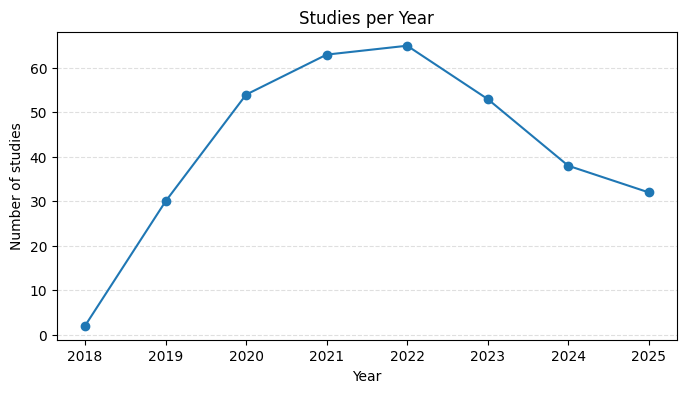

In [6]:
#plot_counts(df, 'year', "Studies per Year", is_exploded=False)

df['year'].value_counts()\
    .sort_index()\
    .plot(kind="line", marker="o", figsize=(8,4))
plt.xlabel("Year")
plt.ylabel("Number of studies")
plt.title("Studies per Year")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.show()



 Plot saved as publication-ready PDF: /content/model_task_by_year.pdf


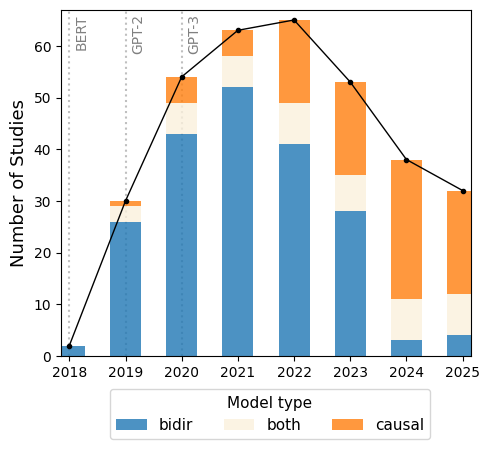

In [7]:
# time and barplot below with the amount of different model types
year_counts = df['year'].value_counts().sort_index()

# Model-type counts per year
task_counts = (
    df.groupby(['year', 'model_type'])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)
# Align indices
years = year_counts.index
x = np.arange(len(years))
fig, ax = plt.subplots(figsize=(5, 4))
bottom = np.zeros(len(x))

handles_for_legend = None
labels_for_legend = None


for task in task_counts.columns:
    ax.bar(
        x,
        task_counts[task].values,
        bottom=bottom,
        label=task,
        width=0.55,
        alpha=0.8,
        zorder=2,
        color=palette.get(task) #palette_darker.get(task)
        )
    bottom += task_counts[task].values

# --- ADD MILESTONE LINES ---
milestones = {2018: "BERT", 2019: "GPT-2", 2020: "GPT-3"} #2022: "ChatGPT/GPT-4"

for year, label in milestones.items():
    if year in years.tolist():
        # Find the x-position for the year
        idx = np.where(years == year)[0][0]
        ax.axvline(x=idx, color='grey', linestyle=':', alpha=0.5, zorder=1)
        # Shift text slightly to the right to avoid overlapping the line
        ax.text(idx + 0.1, ax.get_ylim()[1] * 0.97, label, color='grey',
                rotation=90, fontsize=10, va='top')

if handles_for_legend is None:
    handles_for_legend, labels_for_legend = ax.get_legend_handles_labels()

ax.plot(
    x,
    year_counts.values,
    color="black",
    marker=".",
    linewidth=1.0,
    zorder=3
)

ax.set_xlim(x.min() - 0.15, x.max() + 0.15)

ax.set_xticks(x)
ax.set_xticklabels(years)

plt.subplots_adjust(left=0.12, right=0.95, top=0.90, bottom=0.12)
ax.set_ylabel("Number of Studies",fontsize=13) #weight='bold'
#ax.set_title("Studies per Year with Model type of TLMs",fontsize=15) #weight='bold'
#ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.set_ylim(0, year_counts.max() + 2)

#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

ax.set_ylim(0, year_counts.max() + 2)
#ax.legend(title="Model type", bbox_to_anchor=(0.75, 1), loc="upper left")
fig.legend(
    handles_for_legend,
    labels_for_legend,
    title="Model type",
    title_fontsize=11,
    loc='lower center',
    ncol=len(labels_for_legend),
    bbox_to_anchor=(0.55, -0.13),
    fontsize=11
)


file_name="model_task_by_year.pdf"

try: ## Saving as PDF (vector graphic) with 300 DPI
    plt.savefig(file_name, format='pdf', dpi=300, bbox_inches='tight')
    print(f"\n Plot saved as publication-ready PDF: {os.path.abspath(file_name)}")
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.tight_layout()
plt.show()

## 1.2. By Models

In [8]:
# 2.1 Models category (Causal, bidirectional, both)

plot_counts(df, 'model_type', "Models by Language Modeling Type", is_exploded=False)
percentages = df['model_type'].value_counts(normalize=True) * 100
print(percentages)

model_type
bidir     59.050445
causal    27.299703
both      13.649852
Name: proportion, dtype: float64


In [9]:
# 2.2 Models' language (Monolingual, multilingual, both)

plot_counts(df, 'model_language_coverage', "Models by Language", is_exploded=False)
percentages = df['model_language_coverage'].value_counts(normalize=True) * 100
print(percentages)

model_language_coverage
monolingual     66.468843
multilingual    19.584570
both            13.946588
Name: proportion, dtype: float64



 Plot saved as publication-ready PDF: /content/heatmap_lmcoverage_language.pdf


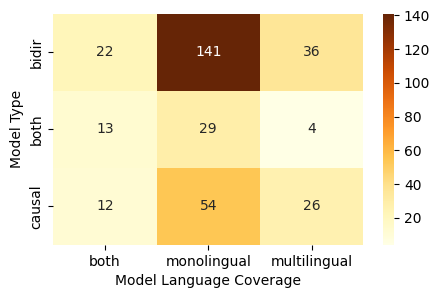

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Model type x family:
pivot = pd.crosstab(df['model_type'], df['model_language_coverage'])
pivot

plt.figure(figsize=(5, 3))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrBr')
#plt.title("Coverage of Model Language Coverage Across Model Type")
plt.xlabel("Model Language Coverage")
plt.ylabel("Model Type")

try:
    plt.savefig("heatmap_lmcoverage_language.pdf", format='pdf', dpi=300, bbox_inches='tight')
    print(f"\n Plot saved as publication-ready PDF: {os.path.abspath("heatmap_lmcoverage_language.pdf")}")
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

## 1.3 Models' family (e.g., BERT, GPT2, etc.)


In [11]:
df["model_name_parsed"] = df["model_name"].apply(parse_model_column)

df_models_exploded = df.explode("model_name_parsed", ignore_index=True).dropna(subset=["model_name_parsed"]).reset_index(drop=True)
valid_categories = {"Enc-Only", "Dec-Only"} #"Enc-Dec"

def get_family_if_valid(d):
    if isinstance(d, dict) and d.get("category") in valid_categories:
        return d.get("family")
    return None

def get_category_if_valid(d):
    if isinstance(d, dict) and d.get("category") in valid_categories:
        return d.get("category")
    return None


df_models_exploded["model_fam"] = df_models_exploded["model_name_parsed"].apply(get_family_if_valid)

plot_counts(df_models_exploded, 'model_fam', "Models by Family", is_exploded=False)


 Plot saved as publication-ready PDF: /content/model_by_family_category.pdf


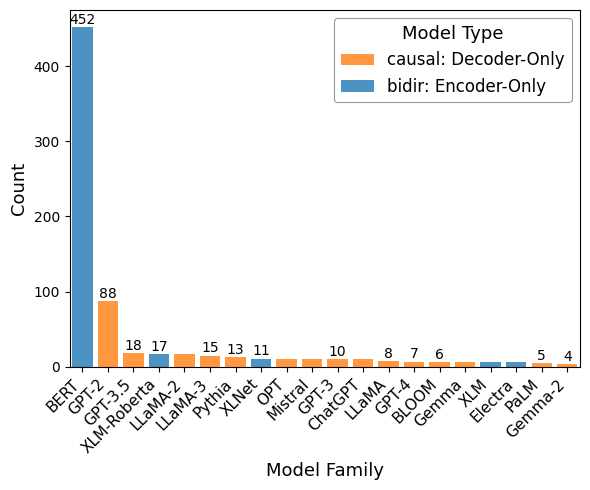

In [12]:
df_models_exploded["model_cat"] = df_models_exploded["model_name_parsed"].apply(get_category_if_valid)

plot_counts_with_category_vertical(df_models_exploded, 'model_cat', 'model_fam', "Models by Family and Category", palette_2, n=20, file_name="model_by_family_category.pdf")
#palette_2

In [13]:
# depth, how many models were tested in each study

df_counts = df_models_exploded.groupby("id")["model_fam"].count()

count_distribution = df_counts.value_counts().sort_index()

fig = px.bar(
        count_distribution,
        title='Distribution of Counts of Model Family Tested per Study',
        labels={"y": "Count of Studies", "x": "Number of Families Tested"}
    )

fig.update_xaxes(tickangle=45, title_text="Number of Model Families Tested")
fig.update_yaxes(tickangle=45, title_text="Count of Studies")

fig.show()

## 1.4 Models specifically

In [14]:
df_models_exploded = df.explode("model_name_parsed", ignore_index=True).dropna(subset=["model_name_parsed"]).reset_index(drop=True)
valid_categories = {"Enc-Only", "Dec-Only"} #"Enc-Dec"

def get_family_if_valid(d):
    #if isinstance(d, dict) and d.get("category") in valid_categories:
    if d.get("model") == "":
        return d.get("family")
    else:
        return d.get("model")
    #return None

df_models_exploded["model_fam"] = df_models_exploded["model_name_parsed"].apply(get_family_if_valid)

plot_counts(df_models_exploded, 'model_fam', "Models by Family", is_exploded=False, n=30)

In [15]:
df_models_exploded["model_fam"].value_counts().head(66
                                                    ) # model tokens


,count
model_fam,
BERT,275
,153
GPT-2,88
RoBERTa,80
mBERT,59
...,...
Wizard,1
eurollm,1
Goldfish,1


In [16]:
# 2.4 Models specifically (e.g., RoBERTa, GPT3 curie, etc.)
# returns nan if the specific model name is unknown

df_models_exploded = df.explode("model_name_parsed", ignore_index=True).dropna(subset=["model_name_parsed"]).reset_index(drop=True)
valid_categories = {"Enc-Only", "Dec-Only"} #"Enc-Dec"

def get_family_if_valid(d):
    if isinstance(d, dict) and d.get("category") in valid_categories:
        if d.get("model") == "":
            return "nan"
        else:
            return d.get("model")
    return None

df_models_exploded["model_fam"] = df_models_exploded["model_name_parsed"].apply(get_family_if_valid)

plot_counts(df_models_exploded, 'model_fam', "Models by Family", is_exploded=False, n=30)

In [17]:
len(df_models_exploded["model_fam"]) # model tokens

1015

In [18]:
# 2.5 Models specifically (e.g., BERT, GPT2, etc.)
# returns model family in case model name is unknown

df_models_exploded = df.explode("model_name_parsed", ignore_index=True).dropna(subset=["model_name_parsed"]).reset_index(drop=True)
valid_categories = {"Enc-Only", "Dec-Only"} #"Enc-Dec"

def get_family_if_valid(d):
    if isinstance(d, dict) and d.get("category") in valid_categories:
        if d.get("model") == "":
            return d.get("family")
        else:
            return d.get("model")
    return None

df_models_exploded["model_fam"] = df_models_exploded["model_name_parsed"].apply(get_family_if_valid)

plot_counts(df_models_exploded, 'model_fam', "Models by Family", is_exploded=False, n=40)

In [19]:
df_models_exploded["model_fam"].value_counts() # model tokens


,count
model_fam,
BERT,275
GPT-2,88
RoBERTa,80
mBERT,59
LLaMA-2,17
XLM-Roberta,16
LLaMA-3,15
Pythia,13
ALBERT,12


In [20]:
# 2.5 Models specifically (e.g., BERT, GPT2, etc.)
# returns model family in case model name is unknown

# SPECIAL COUNTING PER STUDY for BERT family
# --- config ---
single_count_families = {"BERT"}   # families that should be counted at most once PER id

# Start with only valid rows
df_valid = df_models_exploded.dropna(subset=["model_fam"]).copy()

# split into single-count families and others
df_single = df_valid[df_valid["model_fam"].isin(single_count_families)]
df_other  = df_valid[~df_valid["model_fam"].isin(single_count_families)]

# for single-count families, collapse duplicates per (id, family)
df_single_collapsed = (
    df_single
    .groupby(["id", "model_fam"], as_index=False)
    .first()     # keep only 1 per id
)

# Recombine
df_final = pd.concat([df_single_collapsed, df_other], ignore_index=True)

# count normally (bert is max 1 per id; others unlimited)
plot_counts(df_final, "model_fam", "Models by Family", is_exploded=False, n=40)



In [21]:
# SPECIAL COUNTING PER STUDY for ALL model families
# --- config ---
single_count_families = df_models_exploded["model_fam"].dropna().unique().tolist()
# ALL families that should be counted at most once PER id

# Start with only valid rows
df_valid = df_models_exploded.dropna(subset=["model_fam"]).copy()

df_single = df_valid[df_valid["model_fam"].isin(single_count_families)]
df_other  = df_valid[~df_valid["model_fam"].isin(single_count_families)]

df_single_collapsed = (
    df_single
    .groupby(["id", "model_fam"], as_index=False)
    .first()     # keep only 1 per id
)

df_final = pd.concat([df_single_collapsed, df_other], ignore_index=True)
plot_counts(df_final, "model_fam", "Models by Family", is_exploded=False, n=40)



 Plot saved as publication-ready PDF: /content/model_by_family_vertical.pdf


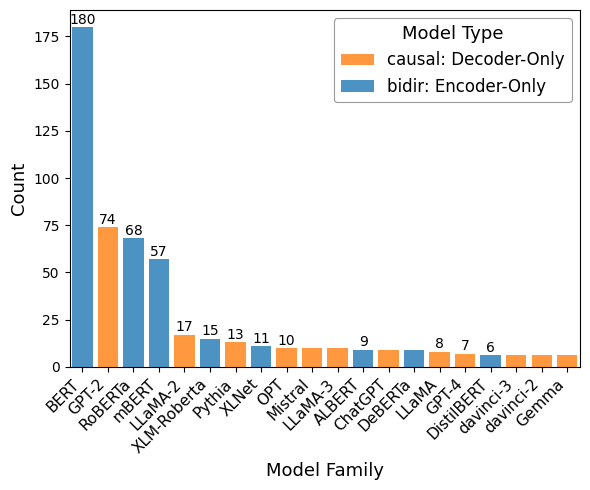

In [22]:
df_models_exploded["model_cat"] = df_models_exploded["model_name_parsed"].apply(get_category_if_valid)
single_count_families = df_models_exploded["model_fam"].dropna().unique().tolist()   # ALL families that should be counted at most once PER id

# Start with only valid rows
df_valid = df_models_exploded.dropna(subset=["model_fam"]).copy()

# 1. Split into single-count families and others
df_single = df_valid[df_valid["model_fam"].isin(single_count_families)]
df_other  = df_valid[~df_valid["model_fam"].isin(single_count_families)]

# 2. For single-count families, collapse duplicates per (id, family)
df_single_collapsed = (
    df_single
    .groupby(["id", "model_fam"], as_index=False)
    .first()     # keep only 1 per id
)
df_final = pd.concat([df_single_collapsed, df_other], ignore_index=True)
plot_counts_with_category_vertical(df_final, 'model_cat', 'model_fam', "Top 20 TLMs by Family/Model Name & Type", palette_2, n=20,  file_name="model_by_family_vertical.pdf")

In [23]:
print(len(single_count_families)) # number of model types 54


54


In [24]:
df_final['model_fam'].value_counts().head(60) # 609 model tokens (if only counted once per study!)

,count
model_fam,
BERT,180
GPT-2,74
RoBERTa,68
mBERT,57
LLaMA-2,17
XLM-Roberta,15
Pythia,13
XLNet,11
OPT,10


In [25]:
len(df_models_exploded["model_name_parsed"])
#len(df_syn[col])

1015

##  Appendix: **Phenomena x Method x Model Type**


 Plot saved as publication-ready PDF: /content/phenomena_model_type.pdf


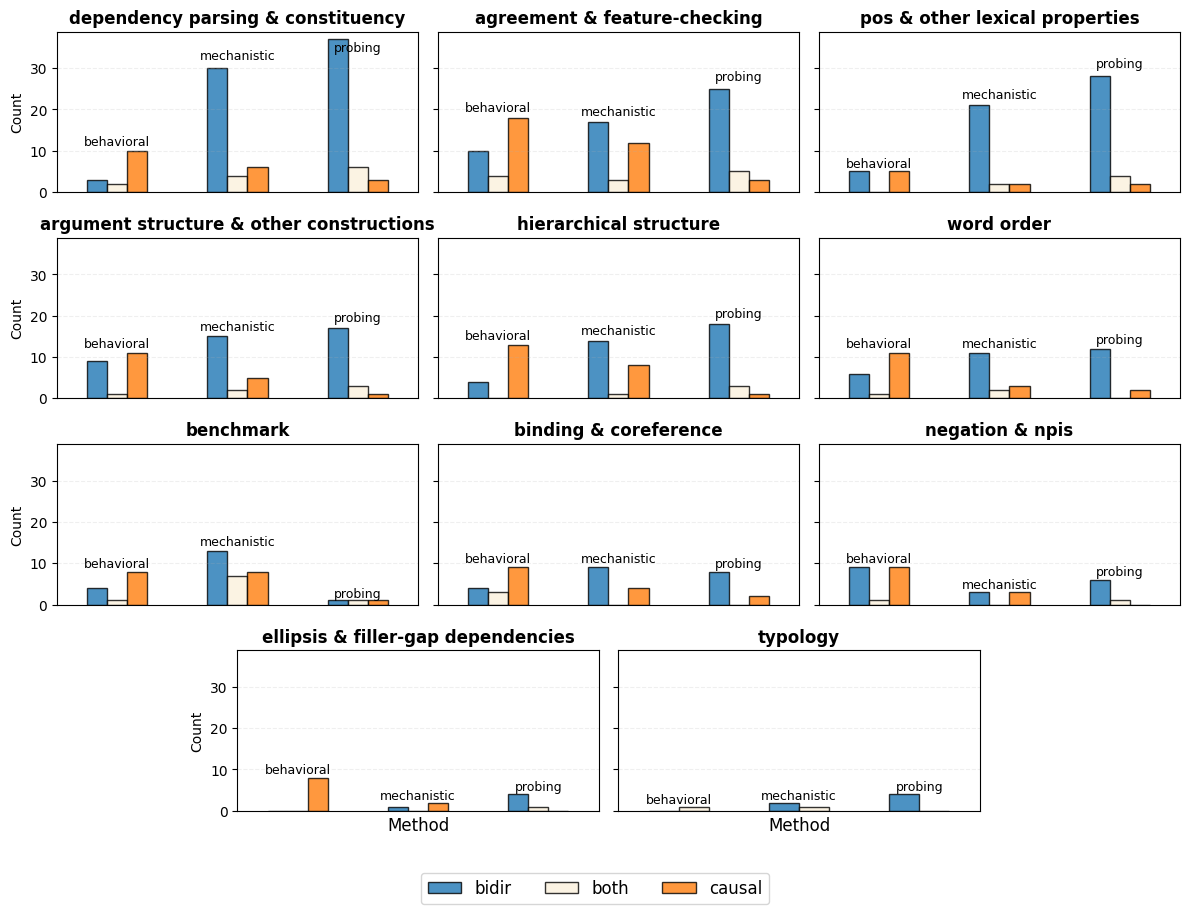

In [26]:
palette = [
    "#1f77b4",  # blue
    "#FAF0DC",  # pink #FF00FF
    "#ff7f0e",  # orange
    "#00FF7F",  # lime green
    #"#9467bd",  # purple
]

palette_colorblind = sns.color_palette("colorblind", n_colors=len(pivot.columns))
hatches = ['\\', 'O', '*'] #['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']

col= "syntactic_phenomena"
df_syn = df.copy()
df_syn[col] = df_syn[col].apply(clean_syntactic_phenomena)
df_syn = df_syn.explode(col).dropna(subset=[col]).copy()

exclude = ["blimp", "cola", "hans", "syntaxgym"]
df_filtered = df_syn[~df_syn[col].isin(exclude)]

# Count per (syntactic_phenomena × method × model_type)
counts = (
    df_filtered
    .groupby(["syntactic_phenomena", "interp_category", "model_type"])
    .size()
    .reset_index(name="count")
)

total_counts = counts.groupby("syntactic_phenomena")["count"].sum()
# Sort phenomena by total counts descending:
phenomena = total_counts.sort_values(ascending=False).index.tolist() #phenomena = counts["syntactic_phenomena"].unique()#[:12]

fig, axes = plt.subplots(4, 3, figsize=(12, 9), sharey=True)
axes = axes.flatten()

handles_for_legend = None
labels_for_legend = None

for i, (ax, phenomenon) in enumerate(zip(axes, phenomena)):
    sub = counts[counts["syntactic_phenomena"] == phenomenon]
    pivot = sub.pivot_table(
        index="interp_category",
        columns="model_type",
        values="count",
        fill_value=0
    )
    pivot.index = pivot.index.str.replace("/", "/\n")

    bar_container = pivot.plot.bar(ax=ax, color=palette, linewidth=1, alpha=0.8, edgecolor='black') #edgecolor='black'


    if handles_for_legend is None:
        handles_for_legend, labels_for_legend = ax.get_legend_handles_labels()

    ax.set_xticks([])
    ax.set_xlabel("")

    plabel = phenomenon.replace(' and ', ' & ').replace('pos', 'pos & other lexical properties') #.replace('benchmark', 'benchmark (= b29 + c11+ sg3 + h1)')

    ax.set_title(plabel, fontsize=12, fontweight="bold")
    ax.set_ylabel("Count")
    if i // 3 == 3:  # last row of 4 rows (0-based index)
        ax.set_xlabel("Method", fontsize=12)
    else:
        ax.set_xlabel("")

    ax.grid(axis="y", linestyle="--", alpha=0.2, zorder=0)

    for i, method in enumerate(pivot.index):
        max_height = pivot.loc[method].max()
        if max_height > 30:
            ypos = max_height * 0.90
            xpos = i + 0.5
            ha = "right"
        else:
            ypos = max_height * 1.05 if max_height > 0 else 0
            xpos = i

        ax.text(
            i, ypos,
            method,
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.get_legend().remove()

for j in range(len(phenomena), len(axes)):
    axes[j].axis("off")

fig.legend(
    handles_for_legend,
    labels_for_legend,
    loc='lower center',
    ncol=len(labels_for_legend),
    bbox_to_anchor=(0.5, -0.02),
    fontsize=12
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

N = 11  # number of plots

for ax in axes[N:]:
    ax.set_visible(False)

plots_in_last_row = N % 3
if plots_in_last_row == 0:
    plots_in_last_row = 3  # full row

empty_slots = 3 - plots_in_last_row

for i in range(N - plots_in_last_row, N):
    box = axes[i].get_position()
    new_x0 = box.x0 + (empty_slots / 2) * box.width
    new_x1 = box.x1 + (empty_slots / 2) * box.width
    axes[i].set_position([new_x0, box.y0, box.width, box.height])

file_name="phenomena_model_type.pdf"

try:
    plt.savefig(file_name, format='pdf', dpi=300, bbox_inches='tight')
    print(f"\n Plot saved as publication-ready PDF: {os.path.abspath(file_name)}")
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

# 2.  Linguistic Phenomena & Language Coverage

## 2.1 **Syntactic phenomena**

a.  Specific classification

b. How many phenomena are tested per paper?

c. Benchmarks: which are used & their distribution

d. Languages tested

### a. Specific classification


--- Calculated Bar Data Dictionary (Total Count and Breakdown) ---
{'typology': {'total_count': np.int64(8), 'breakdown': {'English-Only': '0.0%', 'English & Other': '75.0%', 'Non-English': '25.0%'}}, 'ellipsis and filler-gap dependencies': {'total_count': np.int64(16), 'breakdown': {'English-Only': '62.5%', 'English & Other': '6.2%', 'Non-English': '31.2%'}}, 'negation and npis': {'total_count': np.int64(32), 'breakdown': {'English-Only': '75.0%', 'English & Other': '6.2%', 'Non-English': '18.8%'}}, 'binding and coreference': {'total_count': np.int64(39), 'breakdown': {'English-Only': '84.6%', 'English & Other': '0.0%', 'Non-English': '15.4%'}}, 'benchmark': {'total_count': np.int64(44), 'breakdown': {'English-Only': '79.5%', 'English & Other': '18.2%', 'Non-English': '2.3%'}}, 'word order': {'total_count': np.int64(48), 'breakdown': {'English-Only': '54.2%', 'English & Other': '25.0%', 'Non-English': '20.8%'}}, 'hierarchical structure': {'total_count': np.int64(62), 'breakdown': {'E

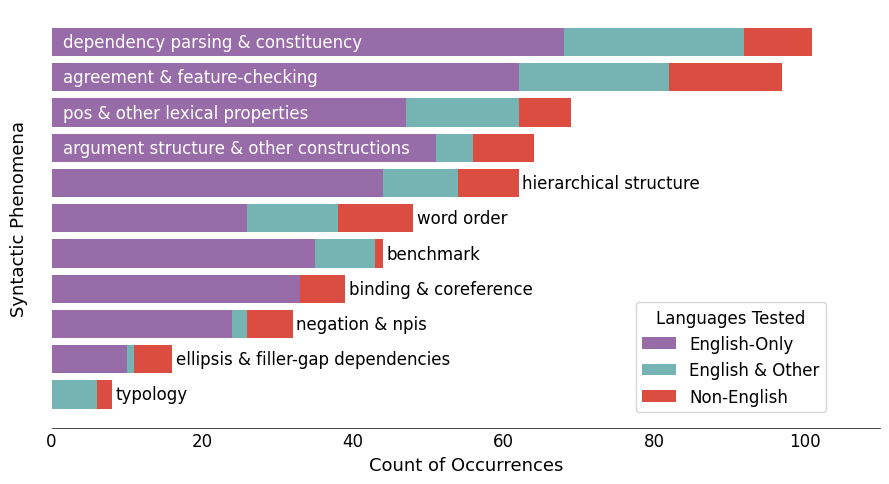

In [27]:
col= "syntactic_phenomena"
df_syn = df.copy()
df_syn[col] = df_syn[col].apply(clean_syntactic_phenomena)
df_syn_exp = df_syn.explode(col).dropna(subset=[col]).copy()

plot_counts_publication_ready_stacked(
    df=df_syn_exp,
    col=col,
    title='Tested Syntactic Phenomena (Classified)',
    file_name="phenomena11_languages.pdf",
    n=20,
    long_bar_threshold=63,  # <--- Use this to define your "long bar" count
    wrap_chars=40)


 Plot saved as publication-ready PDF: /content/phenomena11_languages_nolang.pdf


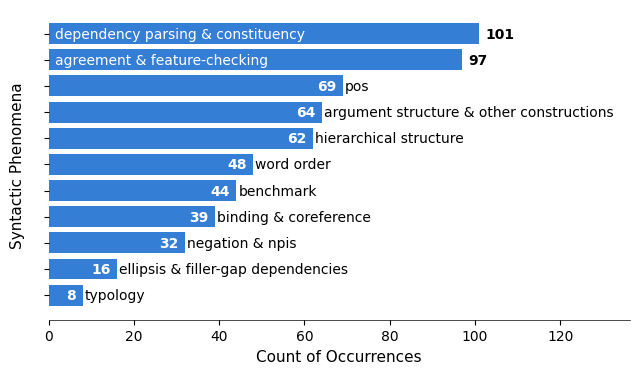

In [28]:
col= "syntactic_phenomena"
df_syn = df.copy()
df_syn[col] = df_syn[col].apply(clean_syntactic_phenomena)
df_syn_exp = df_syn.explode(col).dropna(subset=[col]).copy()

plot_counts_publication_ready(
    df=df_syn_exp,
    col=col,
    title='Tested Syntactic Phenomena (Classified)',
    file_name="phenomena11_languages_nolang.pdf",
    n=20,
    long_bar_threshold=80,  # <--- Use this to define your "long bar" count
    wrap_chars=40)


### b. How many phenomena per paper?


 Plot saved as publication-ready PDF: /content/counts_phenomena.pdf


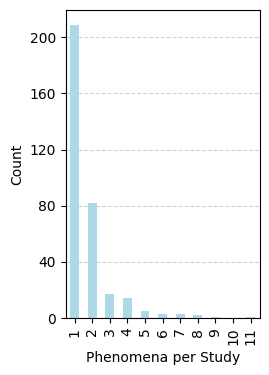

In [29]:

df_syn["num_values"] = df_syn[col].apply(lambda x: len(x))
value_counts = df_syn["num_values"].value_counts().sort_index()

# Create full integer range
full_index = range(value_counts.index.min(),
                   value_counts.index.max() + 1)
value_counts = value_counts.reindex(full_index, fill_value=0)


fig, ax = plt.subplots(figsize=(2.5, 4)) #dpi=300
value_counts.plot(kind="bar", ax=ax,  color="lightblue")
ax.set_xlabel("Phenomena per Study")
ax.set_ylabel("Count")
ax.yaxis.grid(True,  linestyle="--", color="lightgray" )
ax.set_axisbelow(True)  # grid behind bars

# Number of ticks on y-axis
ax.yaxis.set_major_locator(plt.MaxNLocator(7))
#ax.set_title("Distribution of phenomena per paper")

try:
    plt.savefig("counts_phenomena.pdf", format='pdf', dpi=300, bbox_inches='tight')
    print(f"\n Plot saved as publication-ready PDF: {os.path.abspath("counts_phenomena.pdf")}")
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()


In [30]:
percentages = df_syn["num_values"].value_counts(normalize=True).sort_index()
percent_df = percentages.reset_index()
percent_df.columns = ["num_values", "percentage"]
print(percent_df)

   num_values  percentage
0           1    0.620178
1           2    0.243323
2           3    0.050445
3           4    0.041543
4           5    0.014837
5           6    0.008902
6           7    0.008902
7           8    0.005935
8           9    0.002967
9          11    0.002967


### c. Benchmarks: which are used & their distribution

In [31]:
col= "benchmark"
df_syn = df.copy()
df_syn[col] = df_syn[col].apply(clean_syntactic_phenomena)
df_syn_exp = df_syn.explode(col).dropna(subset=[col]).copy()

plot_counts(df_syn_exp, col, "Benchmarks", is_exploded=False)

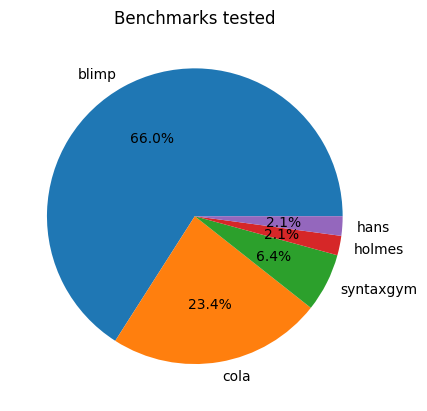

In [32]:
counts = df_syn_exp[col].value_counts()
plt.pie(counts.to_list(), labels=counts.index, autopct='%1.1f%%')
plt.title("Benchmarks tested")
plt.show()

In [33]:
counts

,count
benchmark,
blimp,31
cola,11
syntaxgym,3
holmes,1
hans,1


### d. Languages tested


Plot saved as publication-ready PDF: /content/language_coverage_distribution.pdf


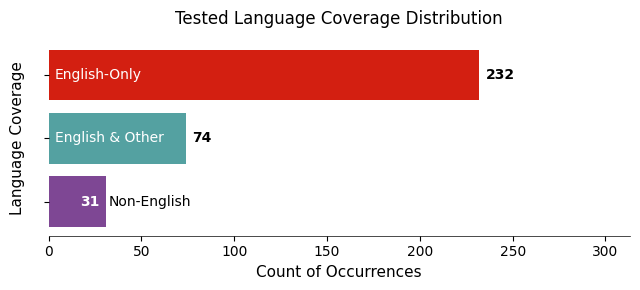

In [34]:
plot_language_coverage_distribution_from_columns(
    df=df,
    title='Tested Language Coverage Distribution',
    file_name='language_coverage_distribution.pdf'
)

In [35]:
(sum(df['languages_tested_monolingual_eng']) + 74)/len(df) # percentage English-Only

0.9080118694362018

## 2.2. **Coverage across LM types**

Divided by:

a. LM task: causal, bidirectional, both

b. Model type: monolingual, multilingual, both

c. Model family


In [36]:
df["model_name_parsed"] = df["model_name"].apply(parse_model_column)

df_models_exploded = df.explode("model_name_parsed", ignore_index=True).dropna(subset=["model_name_parsed"]).reset_index(drop=True)
if df_models_exploded.empty:
  print("No structured model data found after parsing 'model_name'.")

### a. By LLM tasK

In [37]:
df_models_exploded["syntactic_phenomena"] = df["syntactic_phenomena"].apply(clean_syntactic_phenomena)
df_models_exploded = df_models_exploded.explode("syntactic_phenomena").dropna(subset=["syntactic_phenomena"]).copy()

#pivot_percentage = pivot / pivot.values.sum() * 100
pivot = pd.crosstab(df_models_exploded['syntactic_phenomena'], df_models_exploded['model_type'])


 Plot saved as publication-ready PDF: /content/heatmap_lmtask_phenomena.pdf


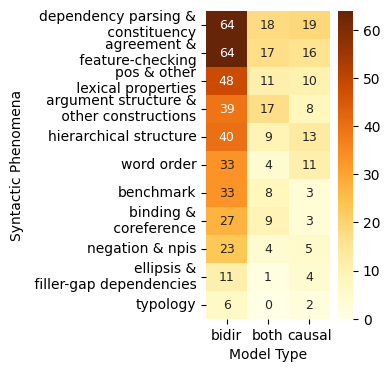

In [38]:
pivot.columns = clean_labels(pivot.columns)
pivot.index = clean_labels(pivot.index)

row_sums = pivot.sum(axis=1)
pivot_ordered_rows = pivot.loc[row_sums.sort_values(ascending=False).index]
col_sums = pivot_ordered_rows.sum(axis=0)

pivot_final_ordered = pivot_ordered_rows.loc[:, col_sums.sort_values(ascending=False).index]

plt.figure(figsize=(2, 4))
sns.heatmap(pivot_final_ordered, fmt='d',annot=True, cmap='YlOrBr', annot_kws={"fontsize": 9}) #YlOrRd PuOr
#plt.title("Coverage of Phenomena Across Model Type")
plt.xlabel("Model Type")
plt.ylabel("Syntactic Phenomena") #weight="bold"
try:
    plt.savefig("heatmap_lmtask_phenomena.pdf", format='pdf', dpi=300, bbox_inches='tight')
    print(f"\n Plot saved as publication-ready PDF: {os.path.abspath("heatmap_lmtask_phenomena.pdf")}")
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()


In [39]:
# Percentages:

pivot_percentage = pivot.div(pivot.sum(axis=1), axis=0) * 100
#pivot_percentage = pivot.div(pivot.sum(axis=0), axis=1) * 100
print("\nPERCENTAGE: normalized by row")
print(pivot_percentage.round(1))

pivot_percentage = pivot.div(pivot.sum(axis=0), axis=1) * 100
print('#'*70,"\nPERCENTAGE: normalized by column")
print(pivot_percentage.round(1))


PERCENTAGE: normalized by row
                                            bidir  both  causal
agreement &\n feature-checking               66.0  17.5    16.5
argument structure &\n other constructions   60.9  26.6    12.5
benchmark                                    75.0  18.2     6.8
binding &\n coreference                      69.2  23.1     7.7
dependency parsing &\n constituency          63.4  17.8    18.8
ellipsis &\n filler-gap dependencies         68.8   6.2    25.0
hierarchical structure                       64.5  14.5    21.0
negation & npis                              71.9  12.5    15.6
pos & other\n lexical properties             69.6  15.9    14.5
typology                                     75.0   0.0    25.0
word order                                   68.8   8.3    22.9
###################################################################### 
PERCENTAGE: normalized by column
                                            bidir  both  causal
agreement &\n feature-checking  

### b. By type (monolingual, multilingual, both)


In [40]:
df["model_name_parsed"] = df["model_name"].apply(parse_model_column)

df_models_exploded = df.explode("model_name_parsed", ignore_index=True).dropna(subset=["model_name_parsed"]).reset_index(drop=True)
if df_models_exploded.empty:
  print("No structured model data found after parsing 'model_name'.")

# create pivot table

df_models_exploded["syntactic_phenomena"] = df["syntactic_phenomena"].apply(clean_syntactic_phenomena)
df_models_exploded = df_models_exploded.explode("syntactic_phenomena").dropna(subset=["syntactic_phenomena"]).copy()

#pivot_percentage = pivot / pivot.values.sum() * 100
pivot = pd.crosstab(df_models_exploded['syntactic_phenomena'], df_models_exploded['model_language_coverage'])

'''df_models_exploded["syntactic_phenomena"] = df["syntactic_phenomena"].apply(clean_syntactic_phenomena).copy()
#df_models_exploded["syntactic_phenomena"] = df["syntactic_phenomena"].apply(clean_syntactic_phenomena)
df_models_exploded = df_models_exploded.explode("syntactic_phenomena").dropna(subset=["syntactic_phenomena"]).copy()

pivot = pd.crosstab(df_models_exploded['syntactic_phenomena'], df_models_exploded['model_language_coverage']) '''




'df_models_exploded["syntactic_phenomena"] = df["syntactic_phenomena"].apply(clean_syntactic_phenomena).copy()\n#df_models_exploded["syntactic_phenomena"] = df["syntactic_phenomena"].apply(clean_syntactic_phenomena)\ndf_models_exploded = df_models_exploded.explode("syntactic_phenomena").dropna(subset=["syntactic_phenomena"]).copy()\n\npivot = pd.crosstab(df_models_exploded[\'syntactic_phenomena\'], df_models_exploded[\'model_language_coverage\']) '

In [41]:
pivot.sum(axis=0)

,0
model_language_coverage,
both,156
monolingual,307
multilingual,117



 Plot saved as publication-ready PDF: /content/heatmap_lmtask_phenomena.pdf


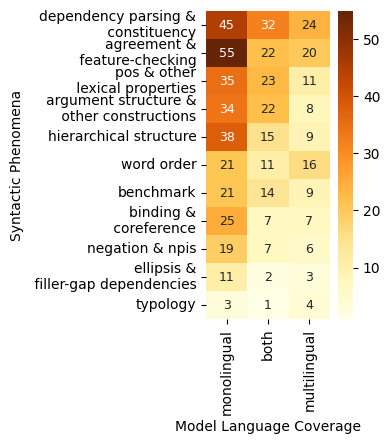

In [42]:
pivot.columns = clean_labels(pivot.columns)
pivot.index = clean_labels(pivot.index)

row_sums = pivot.sum(axis=1)
pivot_ordered_rows = pivot.loc[row_sums.sort_values(ascending=False).index]
col_sums = pivot_ordered_rows.sum(axis=0)

pivot_final_ordered = pivot_ordered_rows.loc[:, col_sums.sort_values(ascending=False).index]


# plot
plt.figure(figsize=(2, 4))
sns.heatmap(pivot_final_ordered, annot=True, fmt='d', cmap='YlOrBr', annot_kws={"fontsize": 9}) #YlOrRd PuOr
#plt.title("Coverage of Phenomena Across Model Type (Language)")
plt.xlabel("Model Language Coverage")
plt.ylabel("Syntactic Phenomena") #weight="bold"

try:
    plt.savefig("heatmap_lmlang_phenomena.pdf", format='pdf', dpi=300, bbox_inches='tight')
    print(f"\n Plot saved as publication-ready PDF: {os.path.abspath("heatmap_lmtask_phenomena.pdf")}")
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

In [43]:
# Percentages

pivot_percentage = pivot.div(pivot.sum(axis=1), axis=0) * 100
print('#'*70,"\nPERCENTAGE: normalized by row")
print(pivot_percentage.round(1))

pivot_percentage = pivot.div(pivot.sum(axis=0), axis=1) * 100
print('#'*70,"\nPERCENTAGE: normalized by column")
print(pivot_percentage.round(1))

###################################################################### 
PERCENTAGE: normalized by row
                                            both  monolingual  multilingual
agreement &\n feature-checking              22.7         56.7          20.6
argument structure &\n other constructions  34.4         53.1          12.5
benchmark                                   31.8         47.7          20.5
binding &\n coreference                     17.9         64.1          17.9
dependency parsing &\n constituency         31.7         44.6          23.8
ellipsis &\n filler-gap dependencies        12.5         68.8          18.8
hierarchical structure                      24.2         61.3          14.5
negation & npis                             21.9         59.4          18.8
pos & other\n lexical properties            33.3         50.7          15.9
typology                                    12.5         37.5          50.0
word order                                  22.9         43.8 

### c. By model family

In [44]:
df["model_name_parsed"] = df["model_name"].apply(parse_model_column)

# explode model_name_parsed first
df_models_exploded = df.explode("model_name_parsed", ignore_index=True).dropna(subset=["model_name_parsed"]).reset_index(drop=True)

# explode syntactic_phenomena separately
df_models_exploded["syntactic_phenomena"] = df_models_exploded["syntactic_phenomena"].apply(clean_syntactic_phenomena)
#df_models_exploded = df_models_exploded.explode("syntactic_phenomena", ignore_index=True).dropna(subset=["syntactic_phenomena"]).reset_index(drop=True)
df_models_exploded = df_models_exploded.explode("syntactic_phenomena").dropna(subset=["syntactic_phenomena"]).copy()

# filter by valid category and get family
valid_categories = {"Enc-Only", "Dec-Only"}

def get_family_if_valid(d):
    if isinstance(d, dict) and d.get("category") in valid_categories:
        return d.get("family")
    return None

df_models_exploded["model_fam"] = df_models_exploded["model_name_parsed"].apply(get_family_if_valid)

pivot = pd.crosstab(df_models_exploded['syntactic_phenomena'], df_models_exploded['model_fam'])


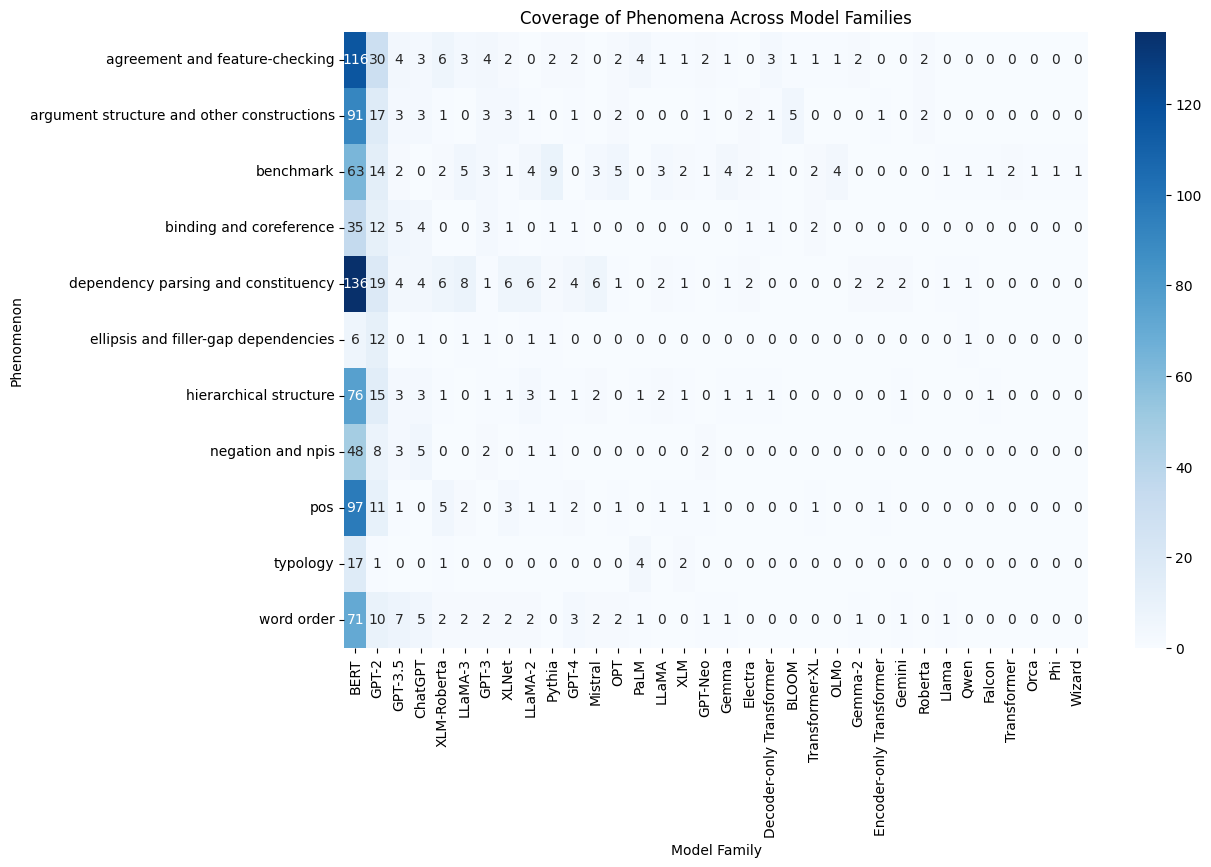

In [45]:
col_sums = pivot.sum(axis=0)
# Sort columns by counts descending
sorted_cols = col_sums.sort_values(ascending=False).index.tolist()
# Reorder pivot columns
pivot = pivot[sorted_cols]


plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')
plt.title("Coverage of Phenomena Across Model Families")
plt.xlabel("Model Family")
plt.ylabel("Phenomenon")
plt.show()

In [46]:
# By model family in case modle name is not available:

df["model_name_parsed"] = df["model_name"].apply(parse_model_column)

# explode model_name_parsed first (as you did before)
df_models_exploded = df.explode("model_name_parsed", ignore_index=True).dropna(subset=["model_name_parsed"]).reset_index(drop=True)

# explode syntactic_phenomena separately (also safe to explode)
df_models_exploded["syntactic_phenomena"] = df_models_exploded["syntactic_phenomena"].apply(clean_syntactic_phenomena)
df_models_exploded = df_models_exploded.explode("syntactic_phenomena", ignore_index=True).dropna(subset=["syntactic_phenomena"]).reset_index(drop=True)

# filter by valid category and get family
valid_categories = {"Enc-Only", "Dec-Only"}

def get_family_if_valid(d):
    if isinstance(d, dict) and d.get("category") in valid_categories:
        if d.get("model") == "":
            return d.get("family")
        else:
            return d.get("model")
    return None

df_models_exploded["model_fam"] = df_models_exploded["model_name_parsed"].apply(get_family_if_valid)

pivot = pd.crosstab(df_models_exploded['syntactic_phenomena'], df_models_exploded['model_fam'])

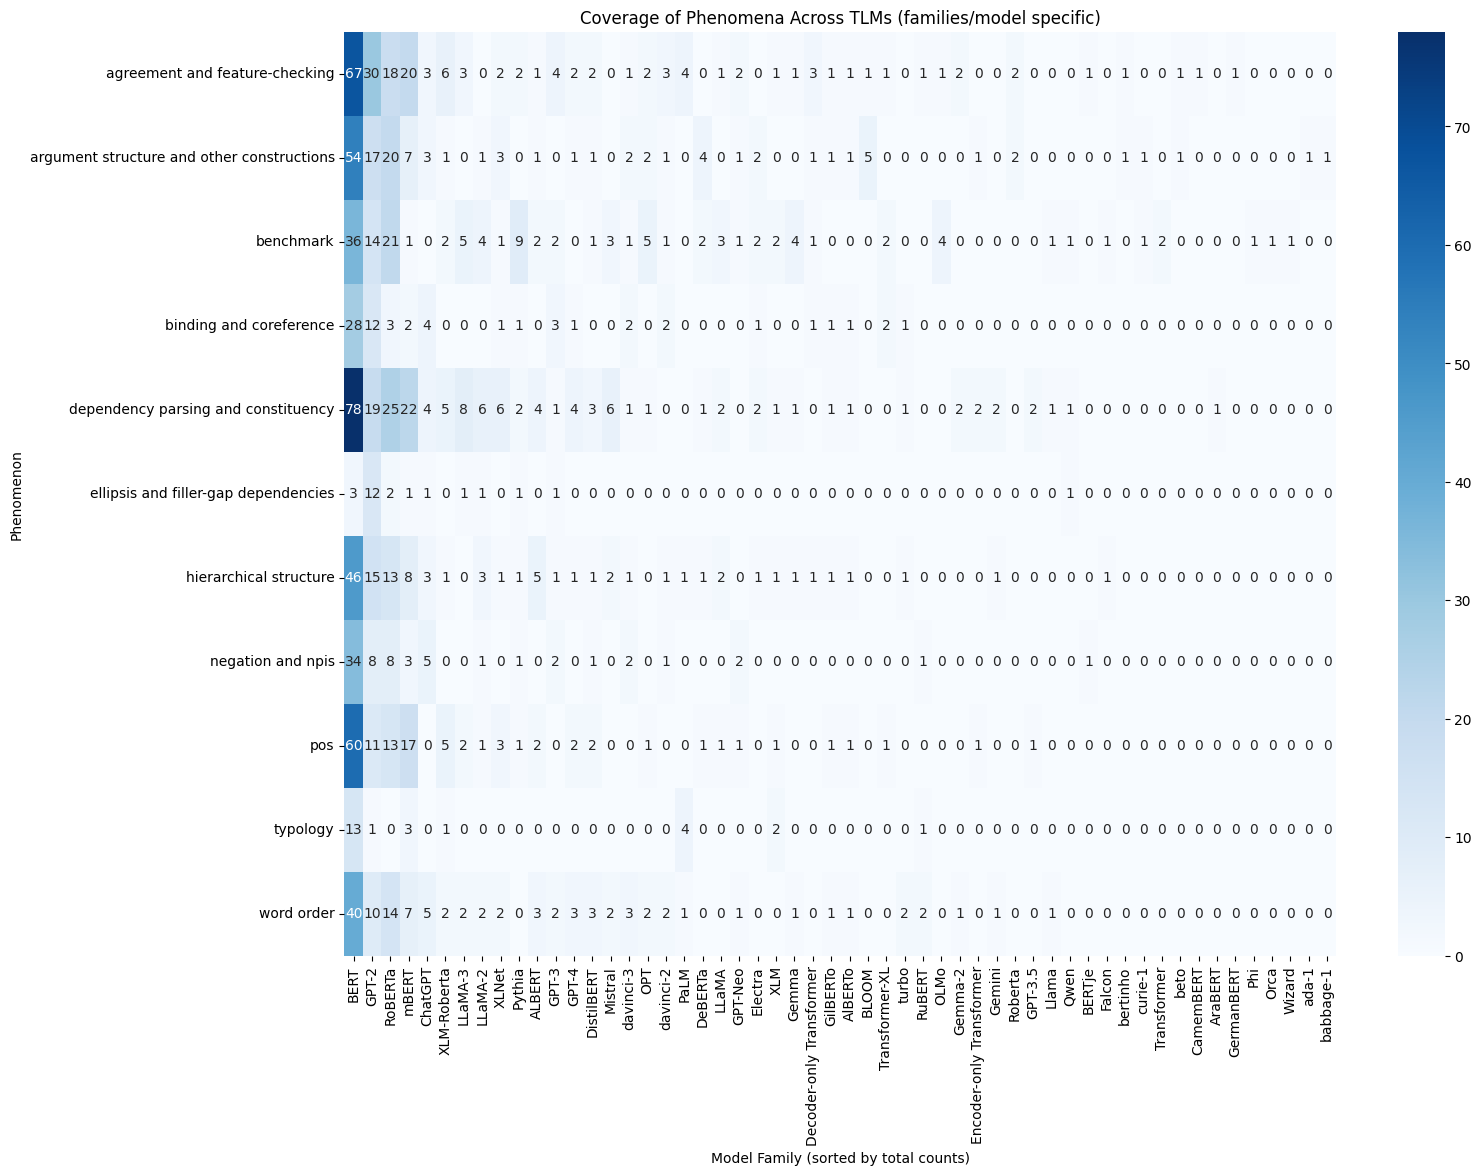

In [47]:
col_sums = pivot.sum(axis=0)
# Sort columns by counts descending
sorted_cols = col_sums.sort_values(ascending=False).index.tolist()
# Reorder pivot columns
pivot = pivot[sorted_cols]


plt.figure(figsize=(16, 12))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')
plt.title("Coverage of Phenomena Across TLMs (families/model specific)")
plt.xlabel("Model Family (sorted by total counts)")
plt.ylabel("Phenomenon")
plt.show()

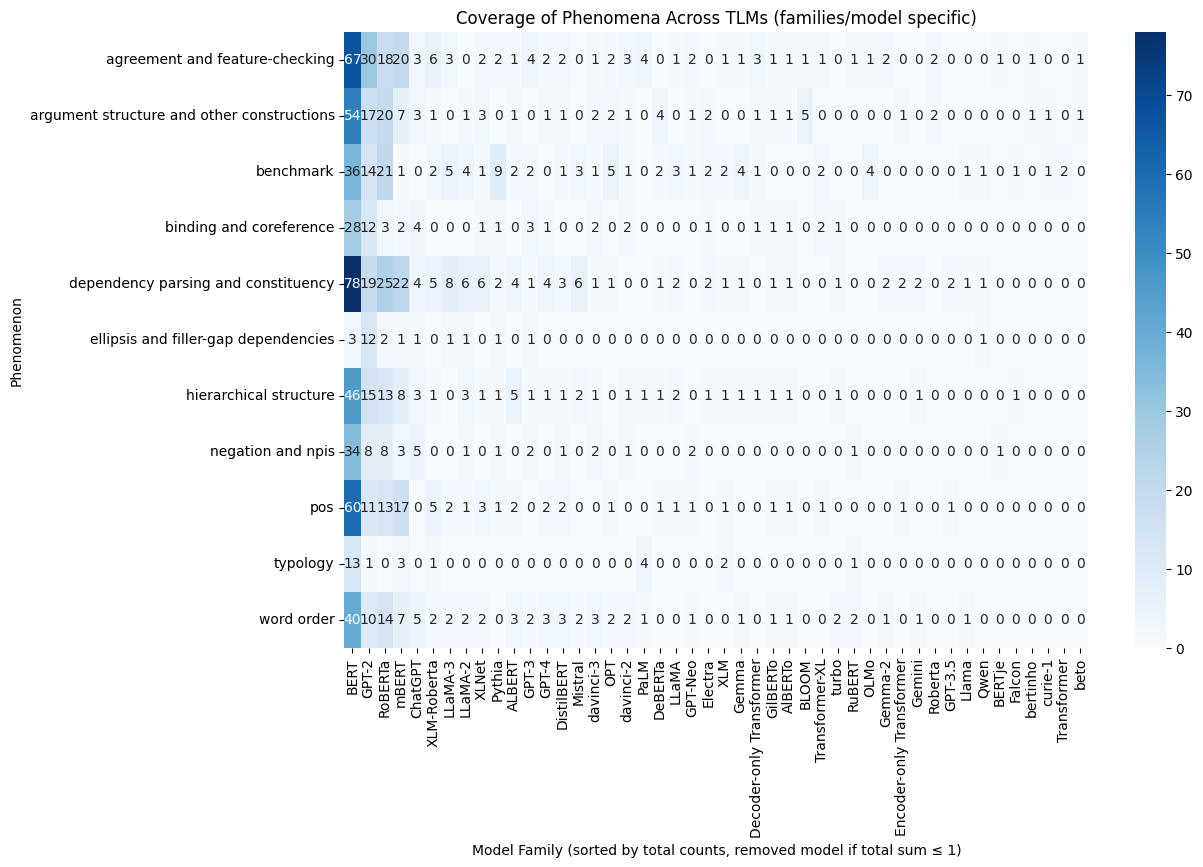

In [48]:
# Remove columns with total count == 1
pivot = pivot.loc[:, pivot.sum(axis=0) != 1]

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')
plt.title("Coverage of Phenomena Across TLMs (families/model specific)")
plt.xlabel("Model Family (sorted by total counts, removed model if total sum ≤ 1)")
plt.ylabel("Phenomenon")
plt.show()

### Appendix: **Trends Over Time**

We don't see an evolution in phenomena across time (peaks for phenomenon = peaks for the overall field)

In [49]:
'''col= "syntactic_phenomena"
df_syn = df.copy()
df_syn[col] = df_syn[col].apply(clean_syntactic_phenomena)
df_syn_exp = df_syn.explode(col).dropna(subset=[col]).copy()

exclude = ["blimp", "cola", "hans", "syntaxgym"]
df_filtered = df_syn_exp[~df_syn_exp[col].isin(exclude)]

yearly = df_filtered.groupby(['year', 'syntactic_phenomena']).size().reset_index(name='count')
phen_counts = df_filtered['syntactic_phenomena'].value_counts()

# colours
happy_bright_palette = [
    "#e6194B",  # vivid red 1
    "#3cb44b",  # bright green
    "#ffe119",  # vibrant yellow
    "#4363d8",  # strong blue
    "#f58231",  # orange
    "#911eb4",  # purple
    "#46f0f0",  # cyan
    "#f032e6",  # magenta
    "#FF6F61",  # orange
    "#984ea3",  # soft pink
    "#008080",  # teal
    "#2A9D8F",  # light purple
]

def rgb_to_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(*rgb)

def shade_color(rgb, factor):
    # factor < 1 darkens, > 1 lightens
    shaded = tuple(min(max(int(c * factor), 0), 255) for c in rgb)
    return shaded



category_color_map = {
    "benchmark": rgb_to_hex(shade_color(OI_colors["OIReddishPurple"], 1.0)),      # OIReddishPurple!45 ~ original
    "misc": rgb_to_hex(OI_colors["OIGrey"]),

    "hierarchical structure": rgb_to_hex(shade_color(OI_colors["OIBlue"], 1.3)),               # blue!30 lighter
    "word order": rgb_to_hex(shade_color(OI_colors["OIBlue"], 1.6)),                            # blue!15 even lighter
    "dependency parsing and constituency": rgb_to_hex(shade_color(OI_colors["OISkyBlue"], 1.3)), # cyan!35 lighter sky blue

    "agreement and feature-checking": rgb_to_hex(shade_color(OI_colors["OIYellow"], 1.4)),      # OIYellow!15 lighter
    "pos":  rgb_to_hex(shade_color(OI_colors["OIYellow"], 1.0)),   # OIYellow!35 original
    "negation and npis": rgb_to_hex(shade_color(OI_colors["OIOrange"], 1.3)),                   # orange!25 lighter
    "binding and coreference": rgb_to_hex(shade_color(OI_colors["OIBluishGreen"], 1.4)),       # OIBluishGreen!15 lighter
    "ellipsis and filler–gap dependencies":rgb_to_hex(shade_color(OI_colors["OIBluishGreen"], 1.0)), # OIBluishGreen!35 original
    "typology": rgb_to_hex(shade_color(OI_colors["OIVermillion"], 1.3)),                        # red!20 lighter
    "argument structure and other constructions":  rgb_to_hex(shade_color(OI_colors["OIReddishPurple"], 1.3)) # brown!25 replaced with lighter reddish purple
}'''



'col= "syntactic_phenomena"\ndf_syn = df.copy()\ndf_syn[col] = df_syn[col].apply(clean_syntactic_phenomena)\ndf_syn_exp = df_syn.explode(col).dropna(subset=[col]).copy()\n\nexclude = ["blimp", "cola", "hans", "syntaxgym"]\ndf_filtered = df_syn_exp[~df_syn_exp[col].isin(exclude)]\n\nyearly = df_filtered.groupby([\'year\', \'syntactic_phenomena\']).size().reset_index(name=\'count\')\nphen_counts = df_filtered[\'syntactic_phenomena\'].value_counts()\n\n# colours\nhappy_bright_palette = [\n    "#e6194B",  # vivid red 1\n    "#3cb44b",  # bright green\n    "#ffe119",  # vibrant yellow\n    "#4363d8",  # strong blue\n    "#f58231",  # orange\n    "#911eb4",  # purple\n    "#46f0f0",  # cyan\n    "#f032e6",  # magenta\n    "#FF6F61",  # orange\n    "#984ea3",  # soft pink\n    "#008080",  # teal\n    "#2A9D8F",  # light purple\n]\n\ndef rgb_to_hex(rgb):\n    return \'#{:02x}{:02x}{:02x}\'.format(*rgb)\n\ndef shade_color(rgb, factor):\n    # factor < 1 darkens, > 1 lightens\n    shaded = tuple

In [50]:
'''top_phens = phen_counts.head(15).index  # top 10 phenomena
df_top = yearly[yearly['syntactic_phenomena'].isin(top_phens)]

fig = px.line(
    df_top,
    x="year",
    y="count",
    color="syntactic_phenomena",
    color_discrete_sequence=happy_bright_palette, #qualitative.Alphabet,
    #color_discrete_map=category_color_map, #px.colors.qualitative.Paired,
    line_dash="syntactic_phenomena",       #color_discrete_sequence=px.colors.qualitative.Vivid ,   # px.colors.qualitative.Dark2
    line_dash_sequence=["solid", "longdashdot", "dot"], #, "dash" "longdashdot" dashdot "longdash" "dot"
    title="Syntactic Phenomena Over Time"
)

fig.update_layout(
    legend=dict(
        orientation="h",   # horizontal legend
        y=-0.2,            # move legend below the plot
        x=0.5,             # center it
        xanchor="center"
    ))

fig.show()'''

'top_phens = phen_counts.head(15).index  # top 10 phenomena\ndf_top = yearly[yearly[\'syntactic_phenomena\'].isin(top_phens)]\n\nfig = px.line(\n    df_top,\n    x="year",\n    y="count",\n    color="syntactic_phenomena",\n    color_discrete_sequence=happy_bright_palette, #qualitative.Alphabet,\n    #color_discrete_map=category_color_map, #px.colors.qualitative.Paired,\n    line_dash="syntactic_phenomena",       #color_discrete_sequence=px.colors.qualitative.Vivid ,   # px.colors.qualitative.Dark2\n    line_dash_sequence=["solid", "longdashdot", "dot"], #, "dash" "longdashdot" dashdot "longdash" "dot"\n    title="Syntactic Phenomena Over Time"\n)\n\nfig.update_layout(\n    legend=dict(\n        orientation="h",   # horizontal legend\n        y=-0.2,            # move legend below the plot\n        x=0.5,             # center it\n        xanchor="center"\n    ))\n\nfig.show()'

# 3. Methods & Mechanistic Interpretability Approaches

## 3.1 **Method Usage Frequency**

a. Trends over time

b. Experimental Materials

c. Model Type

In [51]:
#Calculate how often each method is used.

plot_counts(df, "interp_category", "Frequency of Interpretability Category")

In [52]:
#Calculate how often each method is used.

df.interp_category.value_counts()

,count
interp_category,
mechanistic,140
probing,107
behavioral,90


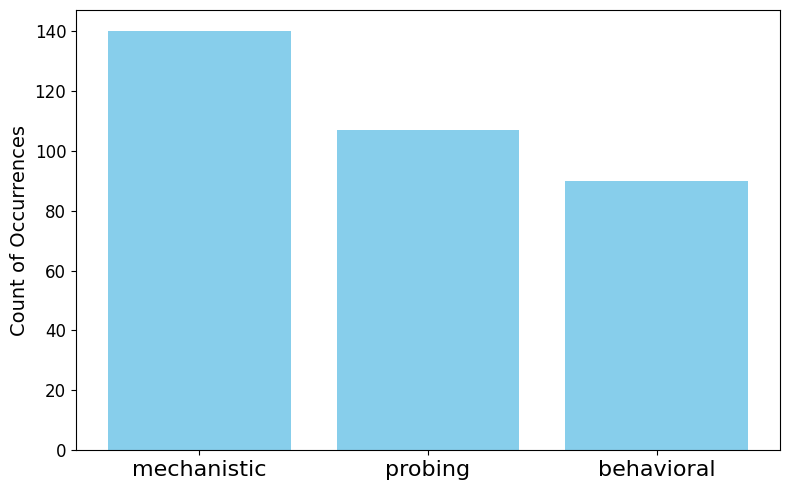

In [53]:
#Calculate how often each method is used.

counts = df.interp_category.value_counts()

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color='skyblue')
plt.ylabel("Count of Occurrences", fontsize=14)
plt.xticks(rotation=0, ha='center', fontsize=16) # Rotate x-axis labels for readability and set font size
plt.yticks(fontsize=12) # Set font size for y-axis labels
plt.tight_layout()
plt.show()

### a. Trends over time

<Axes: xlabel='year'>

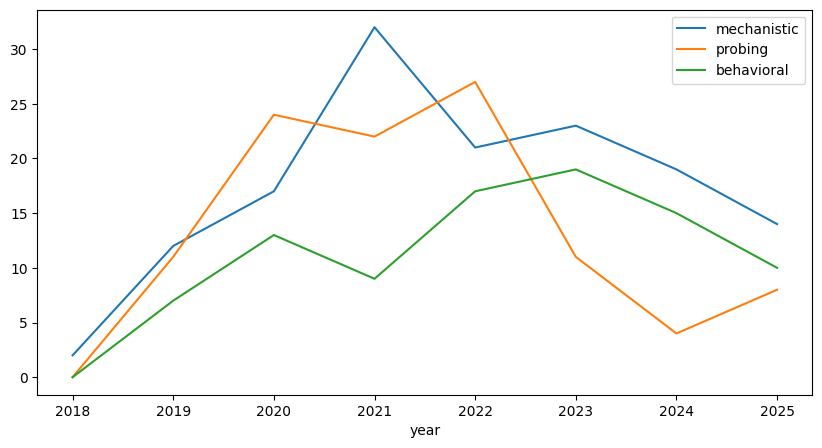

In [54]:
methods = ["mechanistic", "probing", "behavioral"]

for m in methods:
    df[m] = (df["interp_category"] == m).astype(int)

yearly = df.groupby("year")[methods].sum()

yearly.plot(figsize=(10, 5))


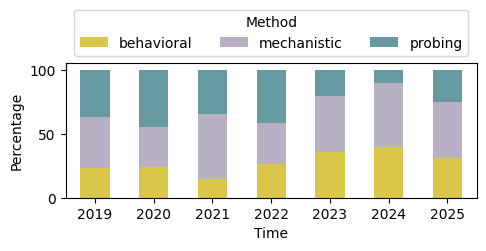

In [55]:
counts = df.groupby(['interp_category', 'year']).size().reset_index(name='n')
counts['year'] = pd.to_numeric(counts['year'].astype(str).str.strip(), errors='coerce')
counts_filtered = counts[counts['year'] >= 2019].dropna(subset=['year']).copy()

counts_filtered['perc'] = counts_filtered.groupby('year')['n'].transform(lambda x: x / x.sum() * 100)
table = counts_filtered.pivot(index='year', columns='interp_category', values='perc')

table.plot(kind='bar', stacked=True, color=custom_colors, figsize=(5, 3), legend=False)

plt.ylabel("Percentage")
plt.xlabel("Time")

plt.legend(
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.4),  # slightly above the plot
    ncol=len(table.columns),
    #fancybox=True,
    #shadow=True,
    borderaxespad=0.
)
plt.xticks(rotation=0)
plt.tight_layout()

try:
    plt.savefig("method_years_percentage.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

### b. Experimental Materials

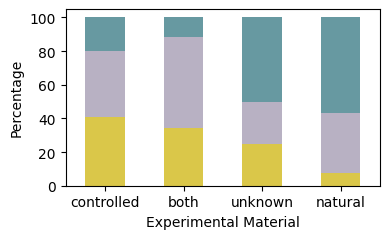

In [56]:
# a barplot with counts for each type of data (natural, controlled, etc.)

counts = df.groupby(['interp_category', 'experimental_materials']).size().reset_index(name='n')
counts['perc'] = counts.groupby('experimental_materials')['n'].transform(lambda x: x / x.sum() * 100)
table = counts.pivot(index='experimental_materials', columns='interp_category', values='perc')

first_column_name = table.columns[0]
table = table.sort_values(by=first_column_name, ascending=False)

table.plot(kind='bar', stacked=True, color= custom_colors, figsize=(4, 2.5), legend=False)
plt.ylabel("Percentage")
plt.xlabel("Experimental Material")
'''plt.legend(
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.2),  # moves legend below
    ncol=len(table.columns)       # optional: all items in one row
)'''
plt.xticks(rotation=0)  # rotate labels 45 degrees
plt.tight_layout()

try:
    plt.savefig('method_exp_material.pdf', format='pdf', dpi=300)
except Exception as e:
    print("\nERROR saving PDF:", e)
plt.show()

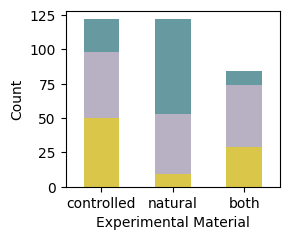

In [57]:
counts = df.groupby(['interp_category', 'experimental_materials']).size().reset_index(name='n')
table = counts.pivot(index='experimental_materials', columns='interp_category', values='n').fillna(0)

table = table[table.sum(axis=1) >= 10]

first_column_name = table.columns[0]
table = table.loc[table.sum(axis=1).sort_values(ascending=False).index]
#table = table.sort_values(by=first_column_name, ascending=False)

table.plot(kind='bar', stacked=True, color=custom_colors, figsize=(3, 2.5), legend=False)
plt.ylabel("Count")
plt.xlabel("Experimental Material")

plt.xticks(rotation=0)
plt.tight_layout()

try:
    plt.savefig('method_exp_material_counts.pdf', format='pdf', dpi=300)
except Exception as e:
    print("\nERROR saving PDF:", e)
plt.show()

### c. Model Type

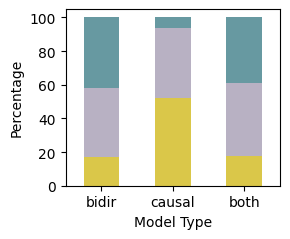

In [58]:
  # method x model_type

counts = df.groupby(['interp_category', 'model_type']).size().reset_index(name='n')

# Step 2: normalize within each time period
counts['perc'] = counts.groupby('model_type')['n'].transform(lambda x: x / x.sum() * 100)
table = counts.pivot(index='model_type', columns='interp_category', values='perc')

#first_column_name = table.columns[0]
#table = table.sort_values(by=first_column_name, ascending=False)
desired_order = ['bidir', 'causal', 'both']
table = table.loc[desired_order]

table.plot(kind='bar', stacked=True, color= custom_colors, figsize=(3, 2.5), legend=False)
plt.ylabel("Percentage")
plt.xlabel("Model Type")
'''plt.legend(
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.2),  # moves legend below
    ncol=len(table.columns)       # optional: all items in one row
)'''
plt.xticks(rotation=0)  # rotate labels 45 degrees
plt.tight_layout()
try:
    plt.savefig('method_modelling_task.pdf', format='pdf', dpi=300)
except Exception as e:
    print("\nERROR saving PDF:", e)
plt.show()

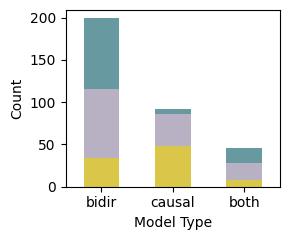

In [59]:
counts = df.groupby(['interp_category', 'model_type']).size().reset_index(name='n')
table = counts.pivot(index='model_type', columns='interp_category', values='n').fillna(0)

table = table[table.sum(axis=1) >= 10]

first_column_name = table.columns[0]
table = table.sort_values(by=first_column_name, ascending=False)

desired_order = ['bidir', 'causal', 'both']
table = table.loc[desired_order]

table.plot(kind='bar', stacked=True, color=custom_colors, figsize=(3, 2.5), legend=False)
plt.ylabel("Count")
plt.xlabel("Model Type")

plt.xticks(rotation=0)
plt.tight_layout()

try:
    plt.savefig('method_modelling_task_counts.pdf', format='pdf', dpi=300)
except Exception as e:
    print("\nERROR saving PDF:", e)
plt.show()

## 3.2 **Methods x Pheonmena**

In [60]:
col= "syntactic_phenomena"
df_syn = df.copy()
df_syn[col] = df_syn[col].apply(clean_syntactic_phenomena)
df_syn = df_syn.explode(col).dropna(subset=[col]).copy()

#exclude = ["blimp", "cola", "hans", "syntaxgym"]
#df_filtered = df_syn[~df_syn[col].isin(exclude)]

plot_counts(df_syn, col, "Tested Syntactic Phenomena (Classified)", is_exploded=False)

In [61]:
method_by_phenomenon = pd.crosstab(df_syn["syntactic_phenomena"], df_syn["interp_category"])
method_by_phenomenon

interp_category,behavioral,mechanistic,probing
syntactic_phenomena,,,
agreement and feature-checking,32,32,33
argument structure and other constructions,21,22,21
benchmark,13,28,3
binding and coreference,16,13,10
dependency parsing and constituency,15,40,46
ellipsis and filler-gap dependencies,8,3,5
hierarchical structure,17,23,22
negation and npis,19,6,7
pos,10,25,34


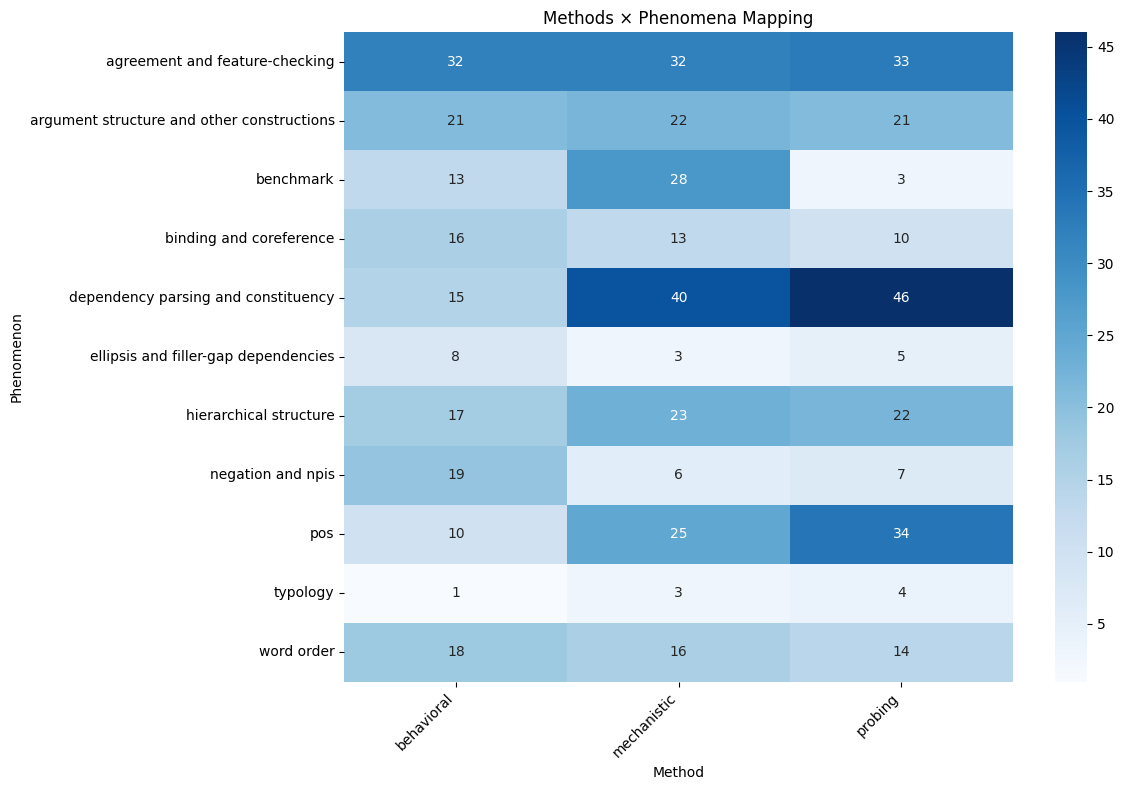

In [62]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    method_by_phenomenon,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Methods × Phenomena Mapping")
plt.xlabel("Method")
plt.ylabel("Phenomenon")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

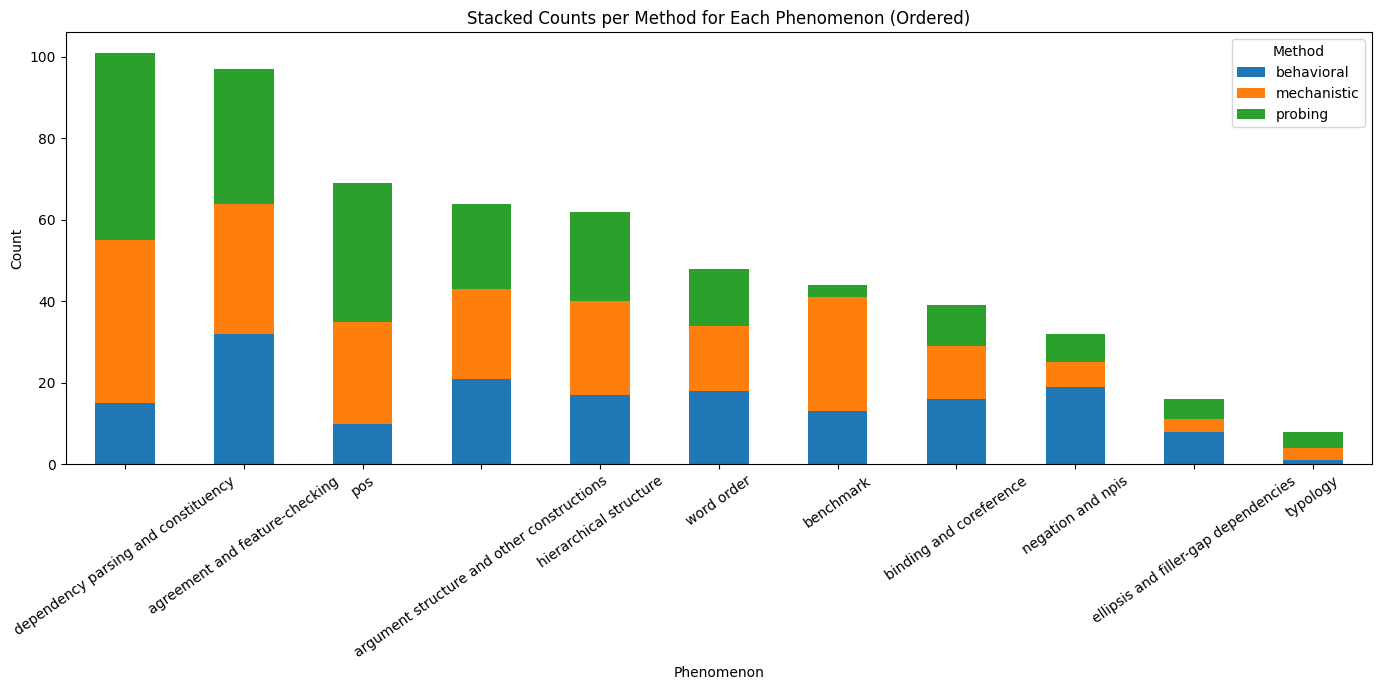

In [63]:
# Calculate total counts per phenomenon (row sum) for counts >=20
totals = method_by_phenomenon.sum(axis=1)

# Sort the DataFrame by the total counts in descending order
method_by_phenomenon_sorted = method_by_phenomenon.loc[totals.sort_values(ascending=False).index]
# Plot
ax = method_by_phenomenon_sorted.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.xlabel("Phenomenon")
plt.ylabel("Count")
plt.title("Stacked Counts per Method for Each Phenomenon (Ordered)")
plt.xticks(rotation=35)
plt.legend(title="Method")
plt.tight_layout()
plt.show()


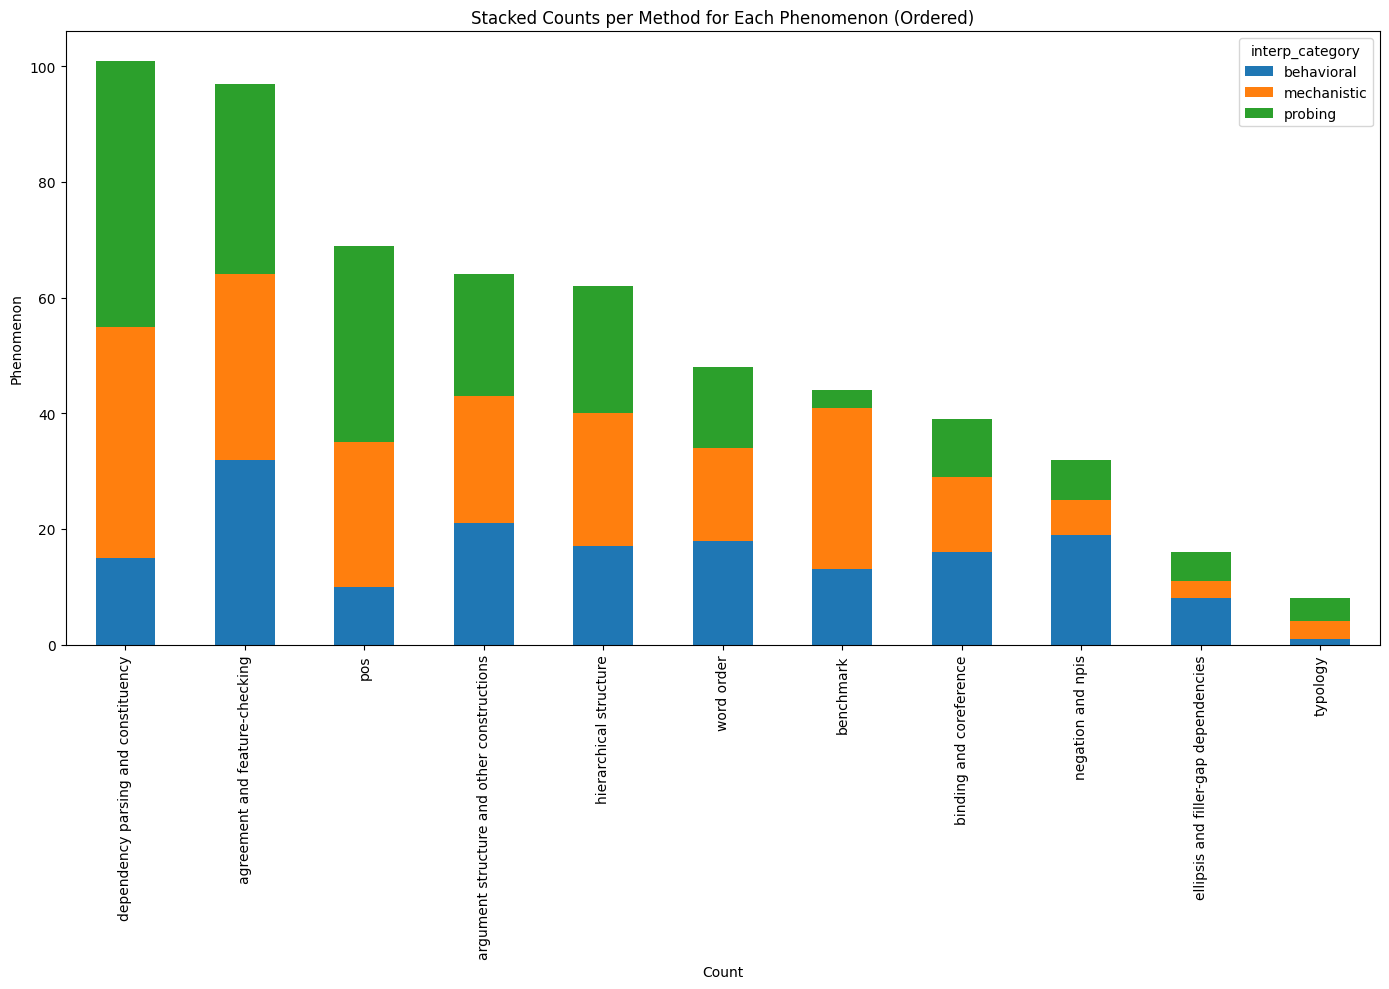

In [64]:
ax = method_by_phenomenon_sorted.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 10)
)
plt.ylabel("Phenomenon")
plt.xlabel("Count")
plt.title("Stacked Counts per Method for Each Phenomenon (Ordered)")
plt.tight_layout()
plt.show()


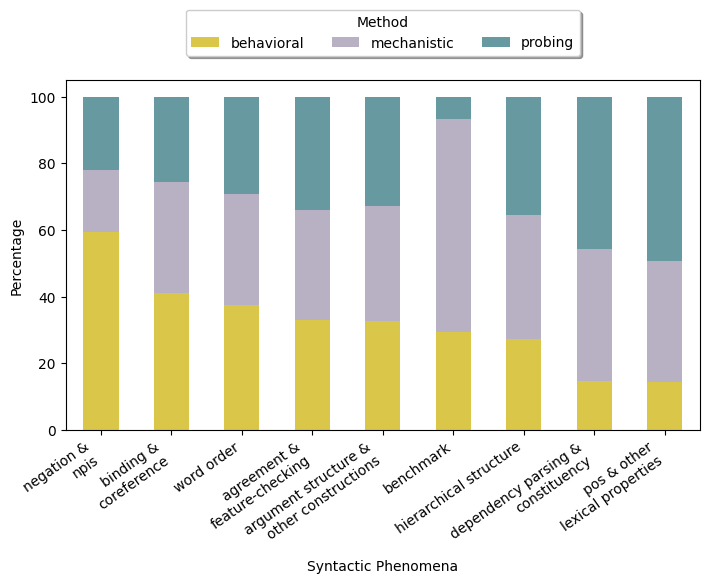

In [65]:
num_methods = len(method_by_phenomenon.columns)
plot_colors = custom_colors[:num_methods]
totals = method_by_phenomenon.sum(axis=1)
method_by_phenomenon_filtered = method_by_phenomenon[totals >= 20].copy()
totals_filtered = method_by_phenomenon_filtered.sum(axis=1)

method_by_phenomenon_normalized = method_by_phenomenon_filtered.div(
    totals_filtered, axis=0
) * 100

first_method_name = method_by_phenomenon_normalized.columns[0]

method_by_phenomenon_sorted = method_by_phenomenon_normalized.sort_values(
    by=first_method_name,
    ascending=False
)

totals_sorted = totals_filtered.loc[method_by_phenomenon_sorted.index]

labels = [
    lbl.replace(' and ', ' &\n')
       .replace('pos', 'pos & other\nlexical properties')
    for lbl in method_by_phenomenon_sorted.index
]

fig, ax = plt.subplots(figsize=(8, 6))


method_by_phenomenon_sorted.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=plot_colors,
    edgecolor='none'
)


plt.xlabel("Syntactic Phenomena")
plt.ylabel("Percentage")
#plt.title(f"Method Distribution per Phenomenon (Total Counts $\geq$ 20, Sorted by '{first_method_name}' Percentage)")

ax.set_ylim(0, 105)

ax.set_xticklabels(labels, rotation=35, ha='right')
plt.legend(
    title="Method",
    bbox_to_anchor=(0.5, 1.05),
    loc='lower center',
    ncol=len(method_by_phenomenon_sorted.columns), # Display legend items horizontally
    fancybox=True,
    shadow=True
)
plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust for legend outside

filename = "method_phenomena_percentage_with_totals.pdf"

try:
    plt.savefig(filename, format='pdf', dpi=300)
except Exception as e:
    print("\nERROR saving PDF:", e)
plt.show()


## **Mechanistic Interpretability**

cross with model type, ling. phenomena, language English and Non-English
Divided by:

a. Overview: mechanistic_interpretability columns (taxonomy)
- Is the approach observational or intervention-based? Causal Nature
- In which Phase do they analyse?
- What part of the model they analyze: Locality

b. What kind of analysis approach: Method

c. Model Type x mechanistic_interpretability columns (taxonomy)

d. Syntactic phenomena x mechanistic_interpretability columns (taxonomy)

e. Language (Eng/Non-Eng) x mechanistic_interpretability columns (taxonomy)


### a. Overview

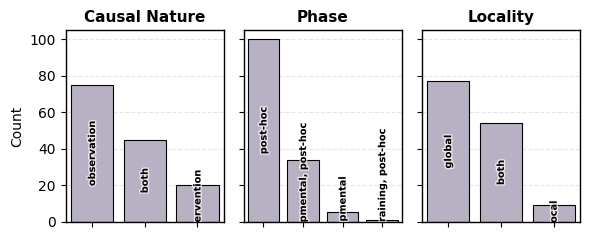

In [66]:
cols = [
    "Mechanistic_Causal Nature",
    "Mechanistic_Phase",
    "Mechanistic_Locality"]


df_subset = df[cols].apply(lambda col: col.str.lower())
cols_to_plot = df_subset.columns[:3]

fig, axes = plt.subplots(1, 3, figsize=(6, 2.5), sharey=True)

for i, col in enumerate(cols_to_plot):
    ax = axes[i]

    top_values = df_subset[col].value_counts().nlargest(15).index

    sns.countplot(
        data=df_subset,
        x=col,
        alpha=1.0,
        saturation=1,
        order=top_values,
        color="#B8B1C3", ##F3CA40
        edgecolor="black",
        linewidth=0.8,
        ax=ax
    )

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)
        spine.set_visible(True)

    for j, p in enumerate(ax.patches):
        height = p.get_height()
        if height > 0:
            txt = ax.text(
                p.get_x() + p.get_width() / 2.,
                height / 2.,
                str(top_values[j]),
                ha='center',
                va='center',
                rotation=90,
                fontsize=7,
                fontweight='bold',
                color='black',
                clip_on=True
            )
            txt.set_path_effects([
                path_effects.withStroke(linewidth=2, foreground='white', alpha=0.7)
            ])

    ax.set_xticklabels([])
    ax.set_xlabel('')
    ax.set_title(col.replace("Mechanistic_",""), fontweight='bold', fontsize=11)

    if i == 0:
        ax.set_ylabel('Count', fontsize=10)
    else:
        ax.set_ylabel('')

    ax.tick_params(axis='y', which='both', left=True, color='black')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("Counts_1x3_Layout.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

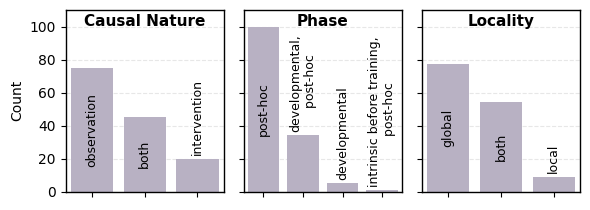

In [67]:
cols_to_plot = df_subset.columns[:3]

fig, axes = plt.subplots(1, 3, figsize=(6, 2.2), sharey=True)

for i, col in enumerate(cols_to_plot):
    ax = axes[i]

    counts = df_subset[col].value_counts().nlargest(15)
    top_values = [str(x).replace(",", ",\n") for x in counts.index]

    sns.countplot(
        data=df_subset,
        x=col,
        alpha=1.0,
        saturation=1,
        order=counts.index,
        color="#B8B1C3", ##F3CA40
        ax=ax, zorder =2
    )

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)
        spine.set_visible(True)

    threshold = counts.max() * 0.35

    for j, p in enumerate(ax.patches):
        height = p.get_height()
        label_text = top_values[j]

        if height < threshold:
            txt = ax.text(
                p.get_x() + p.get_width() / 2.,
                height + 2, # Position slightly above the bar
                label_text,
                ha='center',
                va='bottom',
                rotation=90,
                fontsize=9,
                #fontweight='bold',
                color='black' # High contrast for floating text
            )
        else:
            txt = ax.text(
                p.get_x() + p.get_width() / 2.,
                height / 2.,
                label_text,
                ha='center',
                va='center',
                rotation=90,
                fontsize=9,
                #fontweight='bold',
                color='black'
            )

    ax.set_xticklabels([])
    ax.set_xlabel('')
    ax.set_title(col.replace("Mechanistic_",""), fontsize=11, fontweight='bold', y=0.93, va='top') #
    ax.set_ylim(0, 110) # Extra headroom for floating labels

    if i == 0:
        ax.set_ylabel('Count', fontsize=10)
    else:
        ax.set_ylabel('')

    ax.tick_params(axis='y', which='both', left=True, color='black')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("MICounts_1x3_Layout.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [68]:
df_subset.head()

,Mechanistic_Causal Nature,Mechanistic_Phase,Mechanistic_Locality
0,NaN,NaN,NaN
1,observation,post-hoc,global
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN


/tmp/ipykernel_1874/3536721882.py:25: UserWarning:

The palette list has more values (10) than needed (8), which may not be intended.

/tmp/ipykernel_1874/3536721882.py:25: UserWarning:

The palette list has more values (10) than needed (8), which may not be intended.

/tmp/ipykernel_1874/3536721882.py:25: UserWarning:

The palette list has more values (10) than needed (8), which may not be intended.



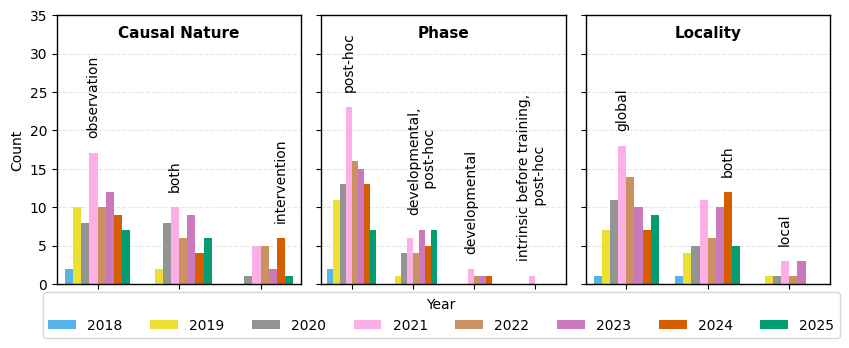

In [69]:

df_subset = df_subset.copy()
df_subset['year'] = df['year']
df_subset = df_subset.dropna(subset=['year'])

cols_to_plot = [c for c in df_subset.columns if c != 'year'][:3]
fig, axes = plt.subplots(1, 3, figsize=(8.5, 3.4), sharey=True)
valid_rows = df_subset[cols_to_plot].dropna(how='all').index
year_order = sorted(df_subset.loc[valid_rows, 'year'].unique())  # Sorted to make legend clean
num_years = len(year_order)

palette_colors = sns.color_palette(sns.color_palette("colorblind")[::-1], n_colors=num_years)
custom_legend_handles = [
    Patch(facecolor=palette_colors[idx], edgecolor='none', label=str(int(yr)))
    for idx, yr in enumerate(year_order)
]

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    df_col_clean = df_subset.dropna(subset=[col])

    counts = df_col_clean[col].value_counts().nlargest(15)
    top_values = [str(x).replace(",", ",\n") for x in counts.index]
    num_categories = len(counts)

    sns.countplot(
        data=df_col_clean,
        x=col,
        hue='year',
        hue_order=year_order,
        order=counts.index,
        alpha=1.0,
        saturation=1,
        palette=sns.color_palette("colorblind")[::-1],
        ax=ax,
        zorder=2
    )

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)
        spine.set_visible(True)

    threshold = counts.max() * 0.35

    category_patches = {cat_idx: [] for cat_idx in range(num_categories)}
    for p in ax.patches:
        h = p.get_height()
        if np.isnan(h) or h == 0:
            continue
        patch_center = p.get_x() + p.get_width() / 2.0
        cat_idx = int(round(patch_center))
        if cat_idx in category_patches:
            category_patches[cat_idx].append(p)

    for cat_idx, patches_list in category_patches.items():
        if not patches_list:
            continue
        label_text = top_values[cat_idx]
        tallest_patch = max(patches_list, key=lambda p: p.get_height())
        height = tallest_patch.get_height()

        if height < threshold:
            ax.text(
                tallest_patch.get_x() + tallest_patch.get_width() / 2.,
                height + 2,
                label_text,
                ha='center', va='bottom', rotation=90, fontsize=10, color='black'
            )
        else:
            ax.text(
                tallest_patch.get_x() + tallest_patch.get_width() / 2.,
                height / 2.,
                label_text,
                ha='center', va='center', rotation=90, fontsize=10, color='black'
            )

    ax.set_xticklabels([])
    ax.set_xlabel('')
    ax.set_title(col.replace("Mechanistic_",""), fontsize=11, fontweight='bold', y=0.93, va='top')
    ax.set_ylim(0, 35)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    if i == 0:
        ax.set_ylabel('Count', fontsize=10)
    else:
        ax.set_ylabel('')

    ax.tick_params(axis='y', which='both', left=True, color='black')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

clean_year_labels = [str(int(yr)) for yr in year_order]

fig.legend(
    handles=custom_legend_handles,
    labels=clean_year_labels,
    title="Year",
    loc="lower center",
    bbox_to_anchor=(0.525, -0.03),
    ncol=len(clean_year_labels),
    frameon=True,
    fontsize=10,
    title_fontsize=10
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("MICounts_1x3_Layout.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

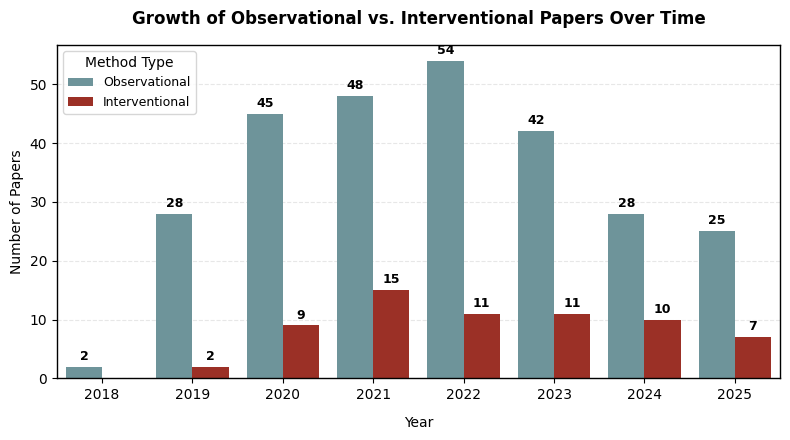

In [70]:
df_subset = df.copy()

def label_method_type(row):
    causal_val = str(row.get('Mechanistic_Causal Nature', '')).strip().lower()
    method_val = str(row.get('interp_category', '')).strip().lower()
    year_val = str(row.get('year', '')).strip().lower()

    if year_val in ['nan', ''] or method_val in ['nan', '']:
        return 'Other'

    if any(x in causal_val for x in ['both', 'intervention']):
        return 'Interventional'

    if any(x in method_val for x in ['behavior', 'probing','mechanistic']):
        return 'Observational'

    return 'Other'

df_subset['method_type'] = df_subset.apply(label_method_type, axis=1)
df_subset = df_subset[df_subset['method_type'] != 'Other']

df_subset['year'] = pd.to_numeric(df_subset['year'], errors='coerce').astype(int)
years_order = sorted(df_subset['year'].unique())

fig, ax = plt.subplots(figsize=(8, 4.5))
type_colors = ['#6799A1', '#ae2012']

sns.countplot(
    data=df_subset,
    x='year',
    hue='method_type',
    hue_order=['Observational', 'Interventional'],
    palette=type_colors,
    ax=ax,
    zorder=2
)

for p in ax.patches:
    height = p.get_height()
    if np.isnan(height) or height == 0:
        continue

    ax.text(
        p.get_x() + p.get_width() / 2.0,
        height + (df_subset['year'].value_counts().max() * 0.01), # Tiny dynamic offset above the bar
        f"{int(height)}",
        ha='center', va='bottom',
        fontsize=9, fontweight='bold',
        color='black'
    )

ax.set_title("Growth of Observational vs. Interventional Papers Over Time", fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=10, labelpad=10)
ax.set_ylabel("Number of Papers", fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.3)

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

ax.legend(title="Method Type", frameon=True, fontsize=9, title_fontsize=10, loc="upper left")

plt.tight_layout()
plt.savefig("method_growth_unified_trend.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

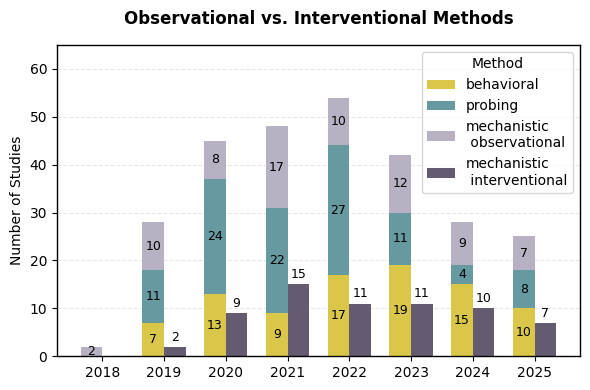

In [71]:
df_subset = df.copy()

def label_detailed_method(row):
    causal_val = str(row.get('Mechanistic_Causal Nature', '')).strip().lower()
    method_val = str(row.get('interp_category', '')).strip().lower()
    year_val = str(row.get('year', '')).strip().lower()

    if year_val in ['nan', ''] or method_val in ['nan', '']:
        return 'other'
    if any(x in causal_val for x in ['both', 'intervention']):
        return 'mechanistic\n interventional'

    if any(x in method_val for x in ['behavior']):
        return 'behavioral'
    if any(x in method_val for x in ['probing']):
        return 'probing'
    if 'mechanistic' in method_val:
        return 'mechanistic\n observational'

    return 'Other'

df_subset['detailed_type'] = df_subset.apply(label_detailed_method, axis=1)
df_subset = df_subset[df_subset['detailed_type'] != 'Other']
df_subset['year'] = pd.to_numeric(df_subset['year'], errors='coerce').astype(int)

pivot_df = df_subset.groupby(['year', 'detailed_type']).size().unstack(fill_value=0)

for col in ['behavioral', 'probing', 'mechanistic\n observational', 'mechanistic\n interventional']:
    if col not in pivot_df.columns:
        pivot_df[col] = 0

fig, ax = plt.subplots(figsize=(6, 4))

years = pivot_df.index
x_indices = np.arange(len(years))
bar_width = 0.35

colors = {
    'behavioral': '#DAC749',
    'probing': '#6799A1',
    'mechanistic\n observational': '#B8B1C3',
    'mechanistic\n interventional': '#645B70' ##ae2012'
}

obs_behav = pivot_df['behavioral']
obs_prob  = pivot_df['probing']
obs_mech  = pivot_df['mechanistic\n observational']

x_obs = x_indices - bar_width / 2

rects_behav = ax.bar(x_obs, obs_behav, bar_width, label='behavioral', color=colors['behavioral'], zorder=2)
rects_prob  = ax.bar(x_obs, obs_prob, bar_width, bottom=obs_behav, label='probing', color=colors['probing'], zorder=2)
rects_mech  = ax.bar(x_obs, obs_mech, bar_width, bottom=obs_behav + obs_prob, label='mechanistic\n observational', color=colors['mechanistic\n observational'], zorder=2)


x_int = x_indices + bar_width / 2
rects_int = ax.bar(x_int, pivot_df['mechanistic\n interventional'], bar_width, label='mechanistic\n interventional', color=colors['mechanistic\n interventional'], zorder=2)

def add_labels_to_stack(rects, label_prefix=""):
    for rect in rects:
        height = rect.get_height()
        if height >= 2:
            y_pos = rect.get_y() + height / 2
            ax.text(
                rect.get_x() + rect.get_width() / 2.0,
                y_pos,
                f"{int(height)}",
                ha='center', va='center',
                fontsize=9, color='black'
            )
        '''else:
            ax.text(
                rect.get_x() + rect.get_width() / 2.0,
                height + (pivot_df.sum(axis=1).max() * 0.01),
                f"{int(height)}",
                ha='center', va='bottom',
                fontsize=9, color='black'
                )'''

add_labels_to_stack(rects_behav)
add_labels_to_stack(rects_prob)
add_labels_to_stack(rects_mech)

for rect in rects_int:
    height = rect.get_height()
    if height > 0:
        ax.text(
            rect.get_x() + rect.get_width() / 2.0,
            height + (pivot_df.sum(axis=1).max() * 0.01),
            f"{int(height)}",
            ha='center', va='bottom',
            fontsize=9, color='black'
        )

ax.set_title("Observational vs. Interventional Methods", fontsize=12, fontweight='bold', pad=15)
ax.set_xticks(x_indices)
ax.set_xticklabels(years, fontsize=10)
#ax.set_xlabel("Year", fontsize=10, labelpad=10)
ax.set_ylabel("Number of Studies", fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.3)

ax.set_ylim(0, pivot_df.sum(axis=1).max())

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

ax.legend(title="Method", frameon=True, fontsize=10, title_fontsize=10, loc="upper right")

plt.tight_layout()
plt.savefig("method_growth_stacked_trend.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

### b. What kind of analysis approach: Method


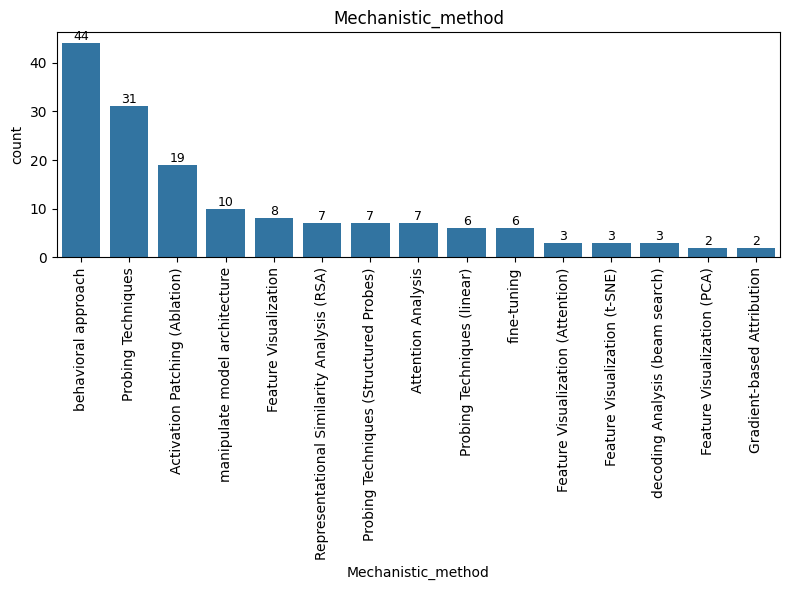

In [72]:
col = 'Mechanistic_method'
df_subset['Mechanistic_method'] =  df['Mechanistic_method'].apply(
    lambda x: [i.strip() for i in str(x).split(',')] if pd.notna(x) else []
)
df_subset_exploded = df_subset.explode('Mechanistic_method').reset_index(drop=True)


plt.figure(figsize=(8,6))

# Get top N values by count
top_values = df_subset_exploded[col].value_counts().nlargest(15).index
ax = sns.countplot(data=df_subset_exploded, x=col, order=top_values)

# Add labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',(p.get_x() + p.get_width() / 2., height),ha='center',va='bottom',fontsize=9
            )

plt.title(col)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [73]:
# method x model type
col = 'Mechanistic_method'
hue_col = 'model_type'

df_subset = df[[col, hue_col]].copy()

df_subset[col] = df[col].apply(
    lambda x: [
        i.lower().strip()
        for i in re.sub(r'\s*\([^)]*\)', '', str(x)).split(',')
        if i.strip()
    ] if pd.notna(x) else []
)

df_subset_exploded = df_subset.explode(col).reset_index(drop=True)



/tmp/ipykernel_1874/1269311215.py:5: UserWarning:

The palette list has more values (4) than needed (3), which may not be intended.



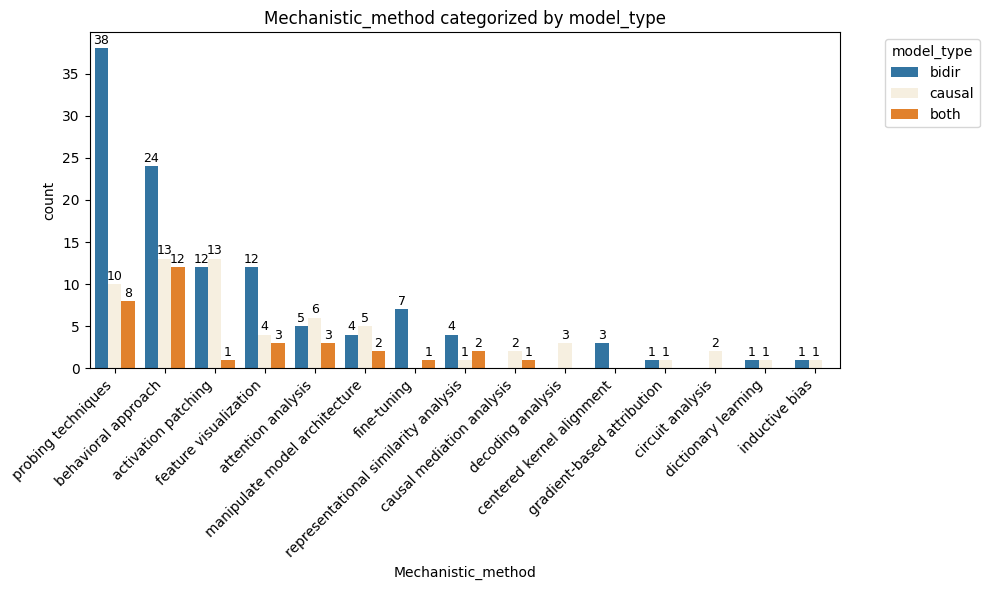

In [74]:
plt.figure(figsize=(10, 6))

top_values = df_subset_exploded[col].value_counts().nlargest(15).index

ax = sns.countplot(
    data=df_subset_exploded,
    x=col,
    hue=hue_col,
    order=top_values,
    palette=palette, # <--- Add this here
    hue_order=['bidir', 'causal', 'both']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=1, fontsize=9)

plt.title(f'{col} categorized by {hue_col}')
plt.xticks(rotation=45, ha='right') # Angled for better readability
plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.tight_layout()
plt.show()

/tmp/ipykernel_1874/244303248.py:6: UserWarning:

The palette list has more values (4) than needed (3), which may not be intended.



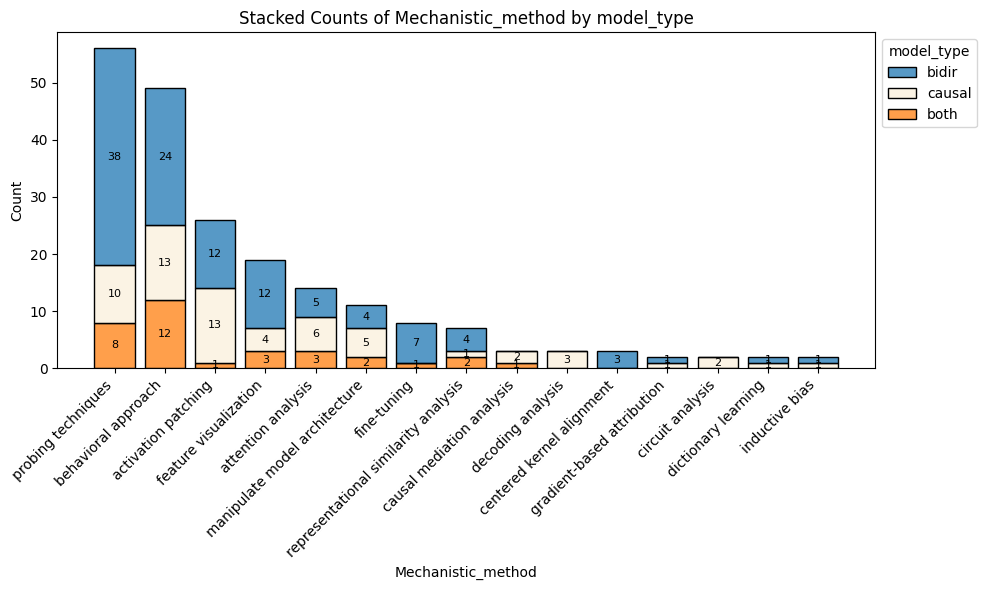

In [75]:
plot_data = df_subset_exploded[df_subset_exploded[col].isin(top_values)].copy()
plot_data[col] = pd.Categorical(plot_data[col], categories=top_values, ordered=True)

plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=plot_data,
    x=col,
    hue=hue_col,
    multiple="stack",
    shrink=0.8,
    legend=True,
    palette=palette, # <--- Add this here
    hue_order=['bidir', 'causal', 'both']
)

for container in ax.containers:
    labels = [int(v.get_height()) if v.get_height() > 0 else "" for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='black')

plt.title(f'Stacked Counts of {col} by {hue_col}')
plt.xticks(rotation=45, ha='right')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig("MImethods_stacked.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1874/2612357871.py:7: UserWarning:

The palette list has more values (4) than needed (3), which may not be intended.



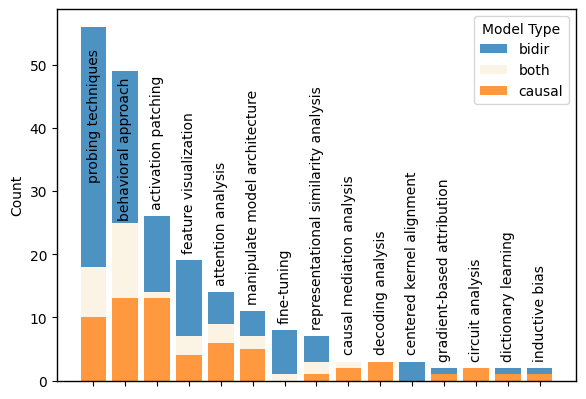

In [76]:
plot_data = df_subset_exploded[df_subset_exploded[col].isin(top_values)].copy()
plot_data[col] = pd.Categorical(plot_data[col], categories=top_values, ordered=True)

plt.figure(figsize=(6, 4.1))
ax = plt.gca()

sns.histplot(
    data=plot_data,
    x=col,
    hue=hue_col,
    multiple="stack",
    shrink=0.8,
    legend=True,
    palette=palette,
    hue_order=['bidir', 'both', 'causal'],
    edgecolor=None, linewidth=0, alpha=0.8,
    ax=ax
)

container_heights = []
for container in ax.containers:
    heights = [rect.get_height() for rect in container]
    container_heights.append(heights)

stacked_heights = np.sum(container_heights, axis=0)

threshold = np.max(stacked_heights) * 0.15

for i, bar_name in enumerate(top_values):
    total_h = stacked_heights[i]
    if total_h <= 0: continue

    if i < 2:  #
        if total_h < threshold:
            ax.text(
                i - 0.45, total_h * 0.8, bar_name,
                va='center', ha='right', rotation=90,
                fontsize=10,  color='black' #fontweight='bold',
            )
        else:
            ax.text(
                i+0.01, total_h * 0.75, bar_name,
                va='center', ha='center', rotation=90,
                fontsize=10, color='black' #fontweight='bold',
            )
    else:
        ax.text(
            i+0.01, total_h + (np.max(stacked_heights) * 0.02), bar_name,
            va='bottom', ha='center', rotation=90,
            fontsize=10, color='black', #fontweight='bold'
            clip_on=False
        )

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)
    spine.set_visible(True)

ax.set_xticklabels([]) # Hide default x labels
ax.set_xlabel('')
ax.tick_params(axis='both', which='both', bottom=True, left=True, color='black')

sns.move_legend(ax, "upper left", bbox_to_anchor=(0.79, 1), title="Model Type",)
plt.tight_layout()
plt.savefig("MImethods_stacked.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [77]:
df_subset_exploded[col].value_counts().nlargest(112).head(17)

,count
Mechanistic_method,
probing techniques,56
behavioral approach,49
activation patching,26
feature visualization,19
attention analysis,14
manipulate model architecture,11
fine-tuning,8
representational similarity analysis,7
causal mediation analysis,3


In [78]:
df_subset_exploded[col].value_counts()

,count
Mechanistic_method,
probing techniques,56
behavioral approach,49
activation patching,26
feature visualization,19
attention analysis,14
...,...
pseudo-log-likelihood scoring,1
pseudo-perplexity,1
adversarial blinding,1


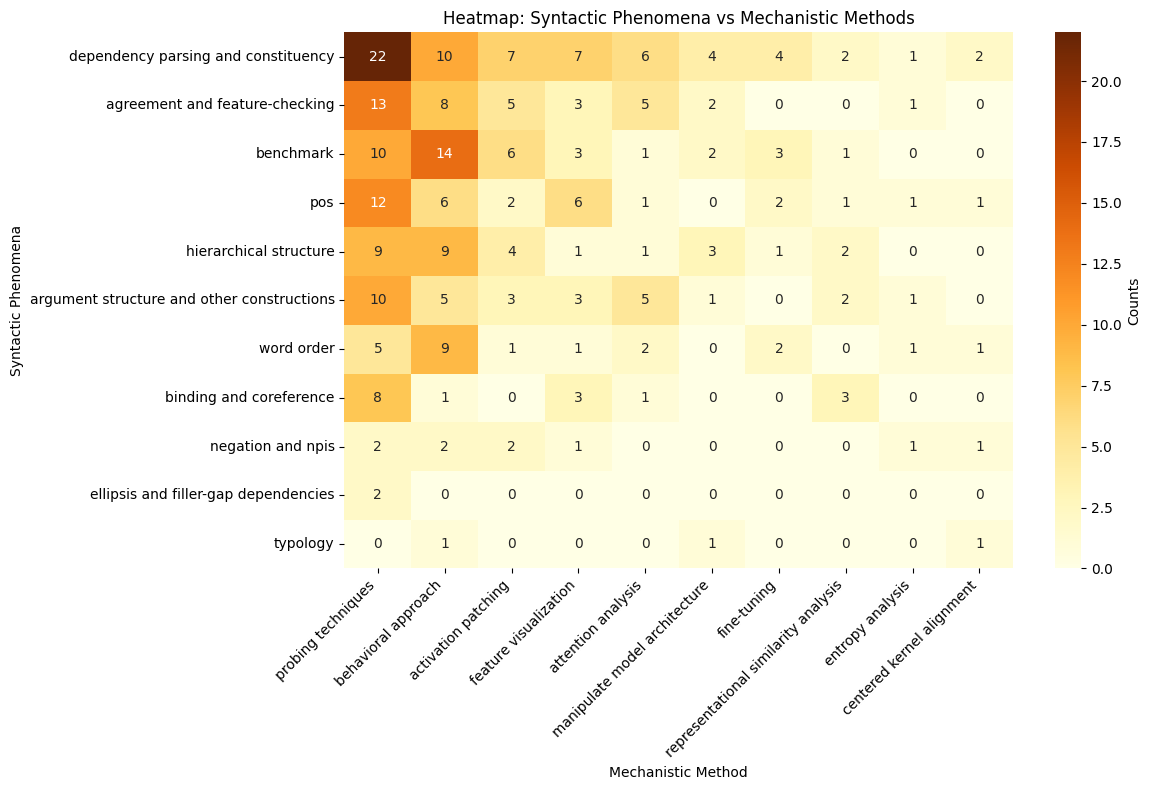

In [79]:
col_syn = "syntactic_phenomena"
col_mech = "Mechanistic_method"

df_heat = df[[col_syn, col_mech]].copy()
df_heat[col_syn] = df_heat[col_syn].apply(clean_syntactic_phenomena)
df_heat = df_heat.explode(col_syn)

df_heat[col_mech] = df_heat[col_mech].apply(
    lambda x: [re.sub(r"\s*\(.*?\)", "", i).lower().strip() for i in str(x).split(',')] if pd.notna(x) else []
)
df_heat = df_heat.explode(col_mech)
df_heat = df_heat.dropna(subset=[col_syn, col_mech])
df_heat = df_heat[(df_heat[col_syn] != "") & (df_heat[col_mech] != "")]

pivot = pd.crosstab(df_heat[col_syn], df_heat[col_mech])

top_syn = df_heat[col_syn].value_counts().nlargest(15).index
top_mech = df_heat[col_mech].value_counts().nlargest(10).index
pivot_filtered = pivot.loc[top_syn, top_mech]

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_filtered,
    annot=True,
    fmt="d",             # Format as integers
    cmap="YlOrBr",
    cbar_kws={'label': 'Counts'}
)

plt.title("Heatmap: Syntactic Phenomena vs Mechanistic Methods")
plt.xlabel("Mechanistic Method")
plt.ylabel("Syntactic Phenomena")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###c. Model Type x mechanistic_interpretability columns (taxonomy)


/tmp/ipykernel_1874/3698294638.py:20: UserWarning:

The palette list has more values (4) than needed (3), which may not be intended.



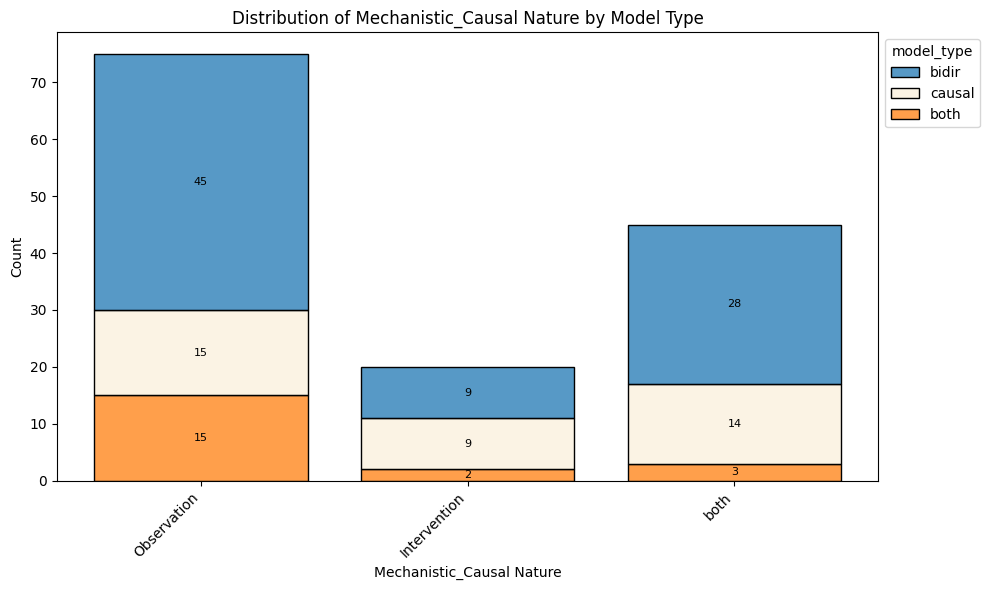

/tmp/ipykernel_1874/3698294638.py:20: UserWarning:

The palette list has more values (4) than needed (3), which may not be intended.



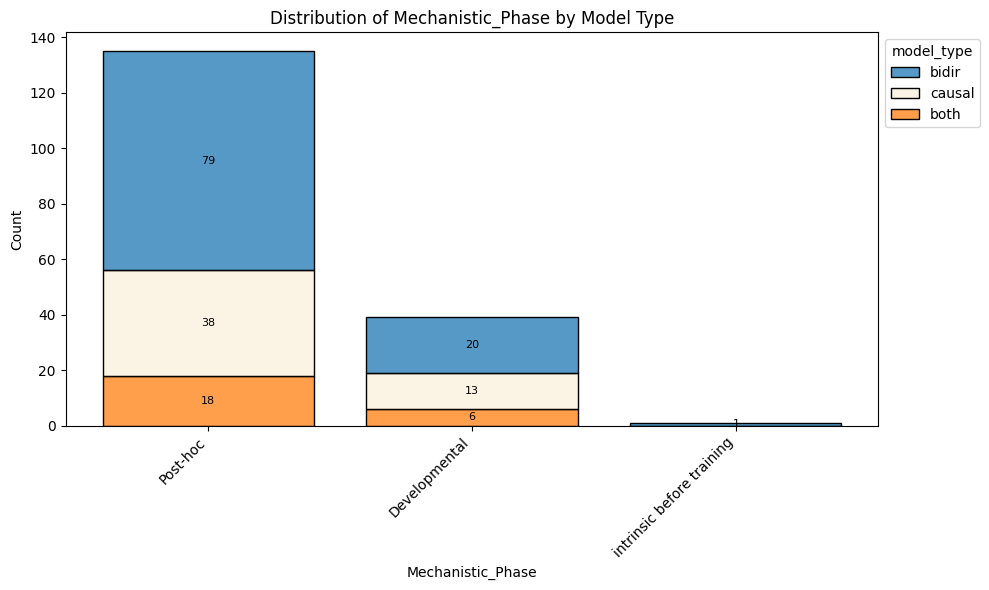

/tmp/ipykernel_1874/3698294638.py:20: UserWarning:

The palette list has more values (4) than needed (3), which may not be intended.



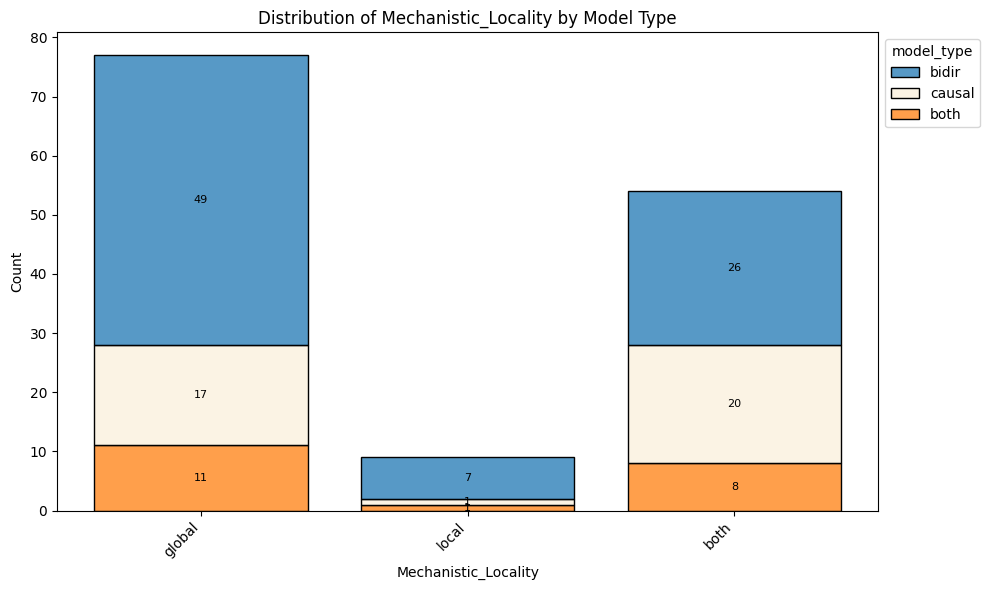

In [80]:
# Configuration
cols = [
    "Mechanistic_Causal Nature",
    "Mechanistic_Phase",
    "Mechanistic_Locality"]
hue_col = 'model_type'
desired_order = ['bidir', 'causal', 'both']
colors = {'bidir': 'skyblue', 'causal': 'orange', 'both': 'purple'}

for col in cols:
    # Prepare data
    df_temp = df[[col, hue_col]].copy()
    df_temp[col] = df_temp[col].apply(lambda x: [i.strip() for i in str(x).split(',')] if pd.notna(x) else [])
    df_temp = df_temp.explode(col).dropna(subset=[col])
    df_temp = df_temp[df_temp[col] != "nan"] # Clean up string 'nan' if present

    plt.figure(figsize=(10, 6))

    # Plot
    ax = sns.histplot(
        data=df_temp,
        x=col,
        hue=hue_col,
        multiple="stack",
        shrink=0.8,
        palette=palette,
        hue_order=desired_order
    )

    # Label non-zero segments
    for container in ax.containers:
        labels = [int(v.get_height()) if v.get_height() > 0 else "" for v in container]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='black')

    plt.title(f"Distribution of {col} by Model Type")
    plt.xticks(rotation=45, ha='right')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

### d. Syntactic phenomena x mechanistic_interpretability columns (taxonomy)

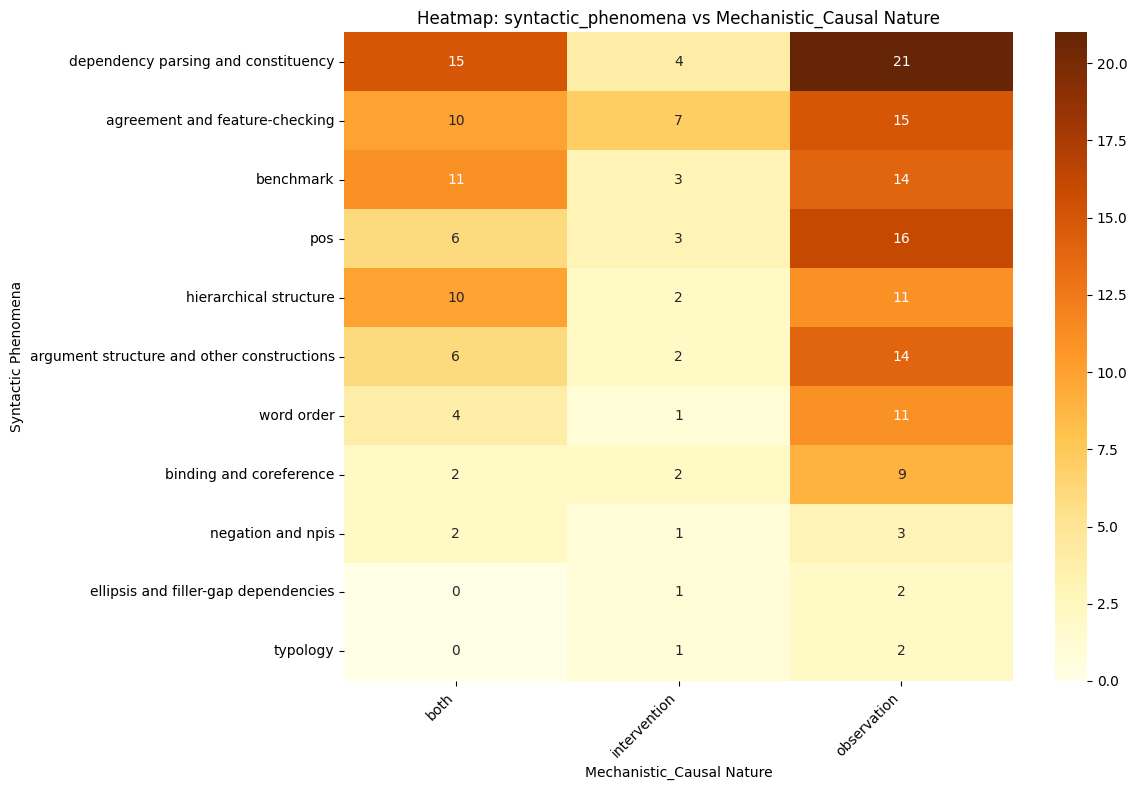

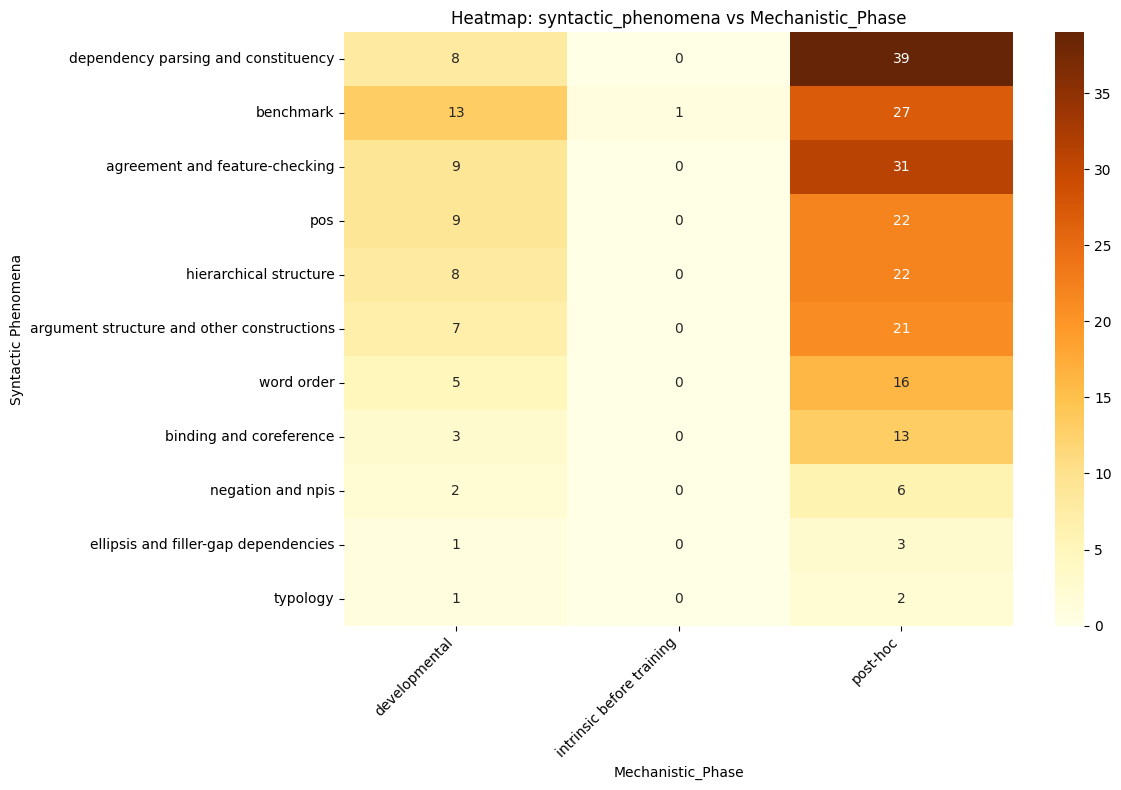

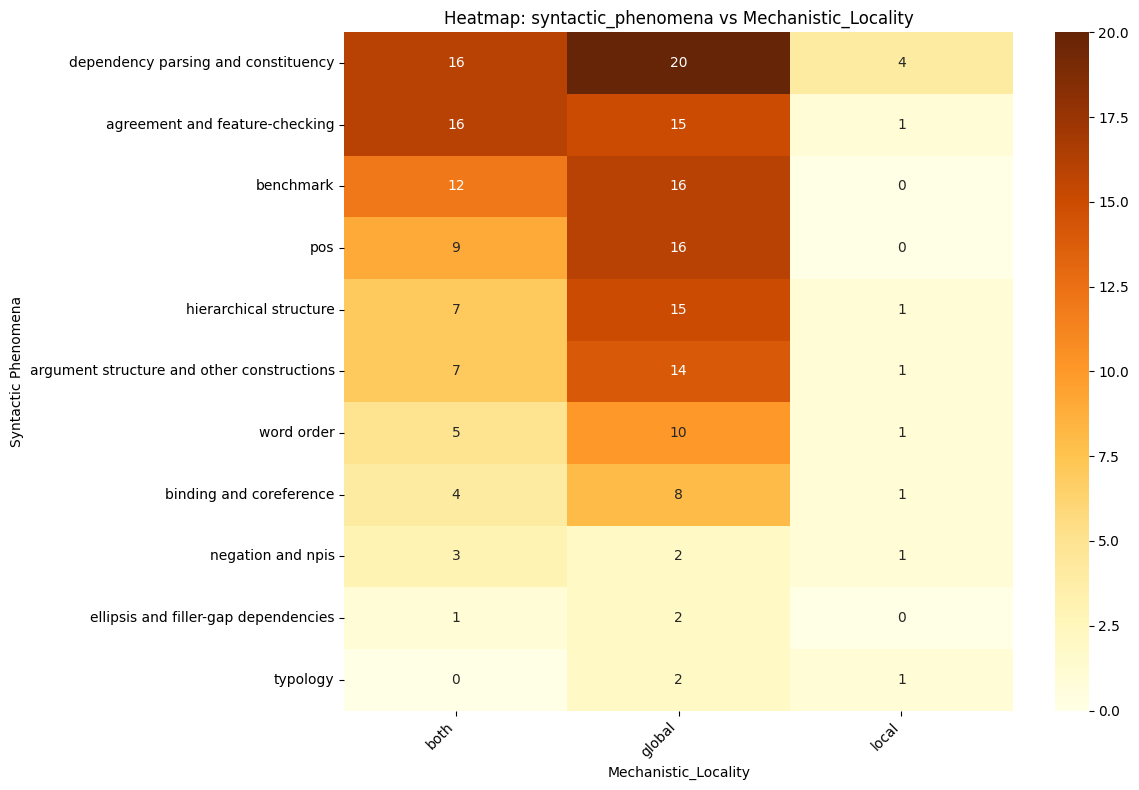

In [81]:
syn_col = "syntactic_phenomena"

for mech_col in cols:
    df_heat = df[[syn_col, mech_col]].copy()
    df_heat[mech_col] = df_heat[mech_col].str.lower()

    df_heat[syn_col] = df_heat[syn_col].apply(clean_syntactic_phenomena)
    df_heat = df_heat.explode(syn_col)

    df_heat[mech_col] = df_heat[mech_col].apply(
        lambda x: [i.strip() for i in str(x).split(',')] if pd.notna(x) else []
    )
    df_heat = df_heat.explode(mech_col)

    df_heat = df_heat.dropna(subset=[syn_col, mech_col])
    df_heat = df_heat[(df_heat[syn_col] != "") & (df_heat[mech_col] != "nan")]

    pivot = pd.crosstab(df_heat[syn_col], df_heat[mech_col])

    # Optional: limit to top 15 phenomena for readability
    top_syn = df_heat[syn_col].value_counts().nlargest(15).index
    pivot = pivot.loc[top_syn]

    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrBr")

    plt.title(f"Heatmap: {syn_col} vs {mech_col}")
    plt.xlabel(mech_col)
    plt.ylabel("Syntactic Phenomena")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### e. Language (Eng/Non-Eng and only English tested, English and other languages, and non-English) x mechanistic_interpretability columns (taxonomy)



/tmp/ipykernel_1874/3353070669.py:23: UserWarning:

The palette list has more values (4) than needed (3), which may not be intended.



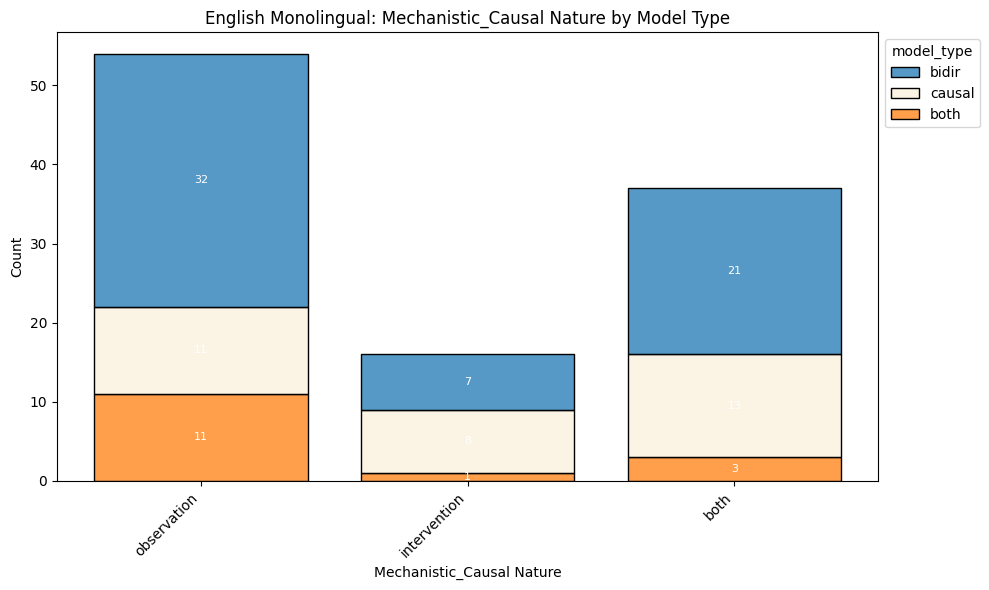

/tmp/ipykernel_1874/3353070669.py:23: UserWarning:

The palette list has more values (4) than needed (3), which may not be intended.



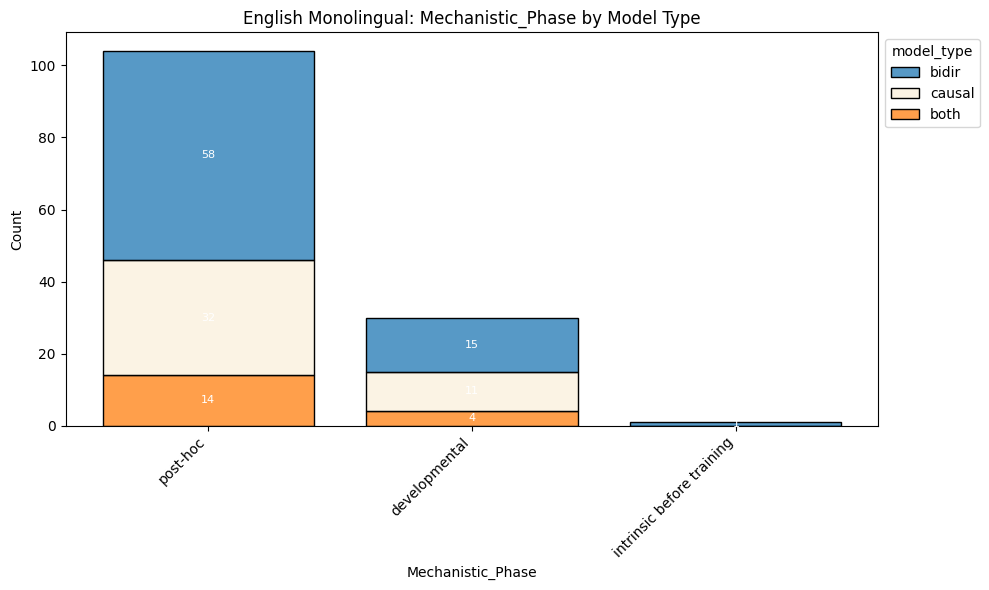

/tmp/ipykernel_1874/3353070669.py:23: UserWarning:

The palette list has more values (4) than needed (3), which may not be intended.



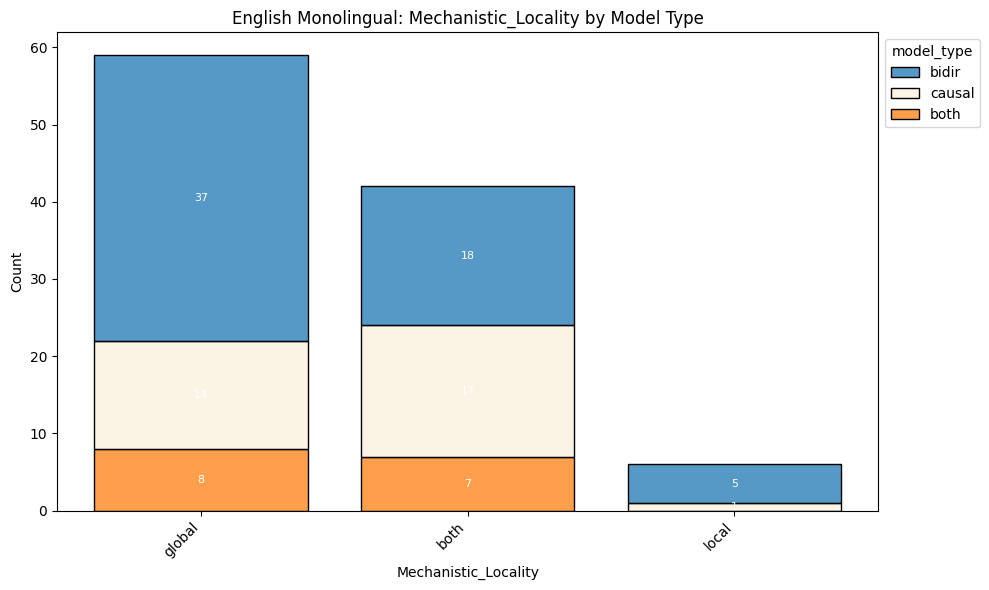

In [82]:
# Filtered for  languages_tested_monolingual_eng ONLY
cols = [
    "Mechanistic_Causal Nature",
    "Mechanistic_Phase",
    "Mechanistic_Locality"]

lang_col = "languages_tested_monolingual_eng"
hue_col = 'model_type'
desired_order = ['bidir', 'causal', 'both']

df_eng = df[df[lang_col] == True].copy()
df_eng[cols] = df_eng[cols].apply(lambda col: col.str.lower())

for col in cols:
    # Prep data
    df_temp = df_eng[[col, hue_col]].copy()
    df_temp[col] = df_temp[col].apply(lambda x: [i.strip() for i in str(x).split(',')] if pd.notna(x) else [])
    df_temp = df_temp.explode(col).dropna(subset=[col])
    df_temp = df_temp[~df_temp[col].isin(["nan", "None", ""])]

    plt.figure(figsize=(10, 6))

    ax = sns.histplot(
        data=df_temp,
        x=col,
        hue=hue_col,
        multiple="stack",
        shrink=0.8,
        palette=palette,
        hue_order=desired_order
    )

    # Label non-zero segments
    for container in ax.containers:
        labels = [int(v.get_height()) if v.get_height() > 0 else "" for v in container]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='white')

    plt.title(f"English Monolingual: {col} by Model Type")
    plt.xticks(rotation=45, ha='right')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

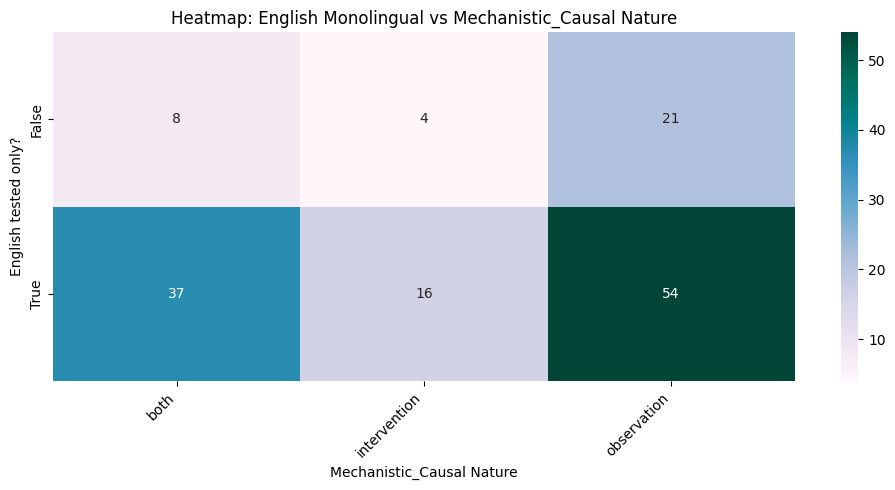

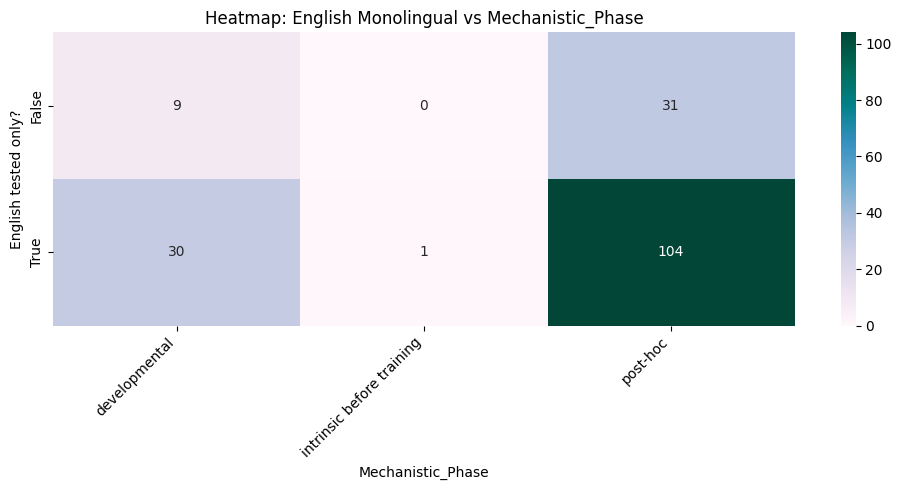

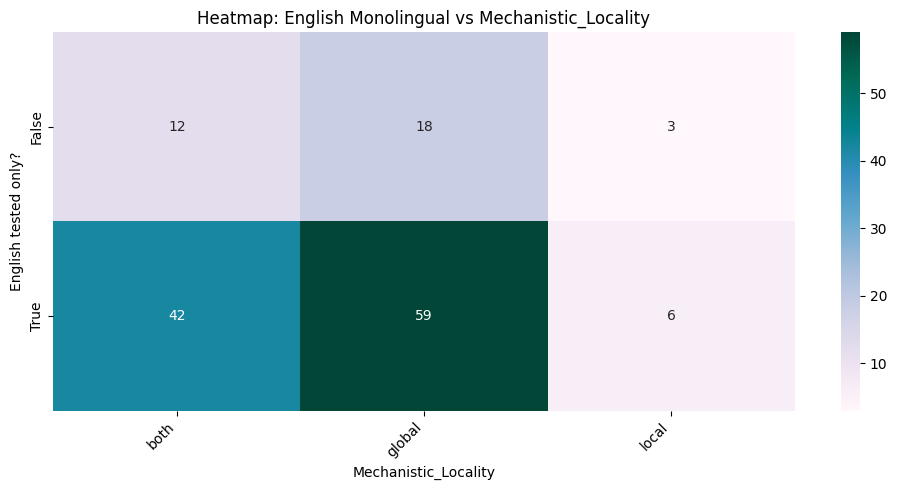

In [83]:
for mech_col in cols:
    df_heat = df[[lang_col, mech_col]].copy()
    df_heat[mech_col] = df_heat[mech_col].str.lower()


    df_heat[mech_col] = df_heat[mech_col].apply(
        lambda x: [i.strip() for i in str(x).split(',')] if pd.notna(x) else []
    )
    df_heat = df_heat.explode(mech_col)

    df_heat = df_heat.dropna(subset=[lang_col, mech_col])
    df_heat = df_heat[~df_heat[mech_col].isin(["nan", "None", ""])]

    pivot = pd.crosstab(df_heat[lang_col], df_heat[mech_col])

    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="PuBuGn")

    plt.title(f"Heatmap: English Monolingual vs {mech_col}")
    plt.xlabel(mech_col)
    plt.ylabel("English tested only?")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

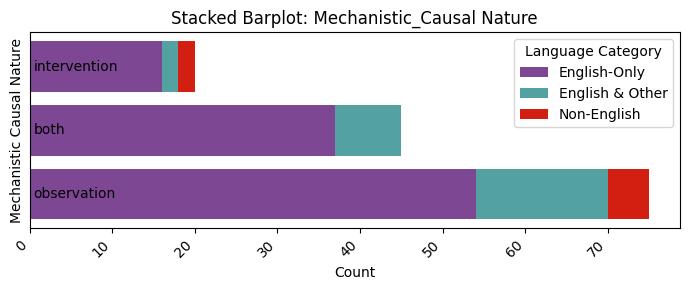

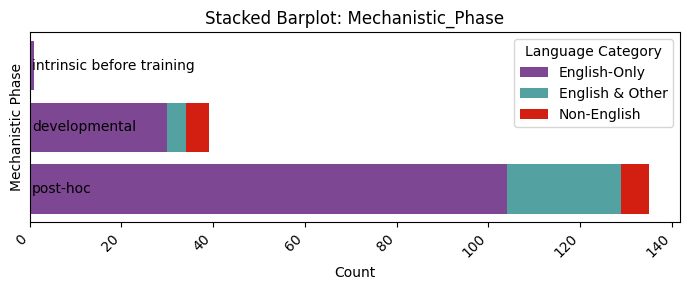

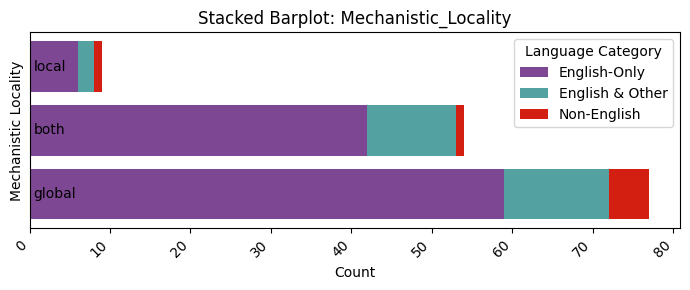

In [84]:

CATEGORY_ORDER = ['English-Only', 'English & Other', 'Non-English']

for mech_col in cols:
    df_plot = df[[syn_col, mech_col,
                  'languages_tested_monolingual_eng',
                  'languages_tested_eng_included']].copy()

    df_plot[mech_col] = df_plot[mech_col].astype(str).str.lower()

    df_plot[mech_col] = df_plot[mech_col].apply(
        lambda x: [i.strip() for i in x.split(',')] if pd.notna(x) else []
    )
    df_plot = df_plot.explode(mech_col)

    df_plot = df_plot.dropna(subset=[mech_col])
    df_plot = df_plot[~df_plot[mech_col].isin(["nan", "none", ""])]

    counts = df_plot[mech_col].value_counts()

    bar_data_dict, stack_df = calculate_bar_data_stacked(df_plot, counts, mech_col)
    plt.figure(figsize=(7, 3))

    bottom = None
    left = None
    for category in CATEGORY_ORDER:
        values = stack_df[category]
        if left is None:
            plt.barh(stack_df.index, values, label=category, color=COLOR_MAP[category])
            left = values.copy()
        else:
            plt.barh(stack_df.index, values, left=left, label=category,color=COLOR_MAP[category])
            left += values
    for i, label in enumerate(stack_df.index):
        plt.text(        0.5, i,  # x-position slightly inside bar, y-position per bar
        label, va='center', ha='left', fontsize=10, color='black'
    )

    plt.yticks([])  # hide default labels

    plt.title(f"Stacked Barplot: {mech_col}")
    plt.xlabel("Count")
    plt.ylabel(mech_col.replace("_", " "))
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Language Category")
    plt.tight_layout()
    plt.show()